# cell 0: setup & environment

In [ ]:
# instalasi dependensi

# google-cloud-bigquery, pandas -> akses dataset via bigquery, pandas sebagai jembatan
# scipy, statsmodel, scikit-learn -> uji statistik non-parametrik, koreksi multiple testing, metrik
# torch -> arsitektur + training DL
# dcor -> untuk distance correlation, ukuran redundansi dalam mRMR
# captum -> untuk feature importance (explainability AI)

%pip install -q google-cloud-bigquery pandas-gbq scipy statsmodels \
    scikit-learn torch dcor captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
# import library
import pandas as pd
import numpy as np
import random
import os
import gc
import warnings
warnings.filterwarnings('ignore')

# bigquery
from google.colab import auth
from google.cloud import bigquery

# mount drive
from google.colab import drive

# scipy, pengujian statistik non-parametrik
import scipy
from scipy.stats import (
    normaltest,    # untuk uji distribusi data (normal/non-normal)
    kruskal,       # untuk kruskal-wallis H-test + relevance score eta^2
)

# statsmodels, koreksi multiple testing
from statsmodels.stats.multitest import multipletests

# distance correlation, ukuran redundansi dalam mRMR
import dcor

# sklearn, preprocessing, dan metrik evaluasi
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score, precision_score,
    confusion_matrix,
)

# arsitektur + training DL
import torch
import torch.nn as nn
import torch.nn.functional as F

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# seed untuk memastikan reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# cudnn determinism, cost ~5-10% throughput tapi memastikan
# dua run dengan seed sama menghasilkan angka identik.
# Trade-off acceptable untuk research reproducibility.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# cek environment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"pandas {pd.__version__} | numpy {np.__version__} | "
      f"scipy {scipy.__version__} | torch {torch.__version__}")
print(f"device : {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print(f"seed   : {RANDOM_SEED} (deterministic cuDNN: on)")

pandas 2.2.2 | numpy 2.0.2 | scipy 1.16.3 | torch 2.10.0+cu128
device : cuda (Tesla T4)
seed   : 42 (deterministic cuDNN: on)


In [ ]:
# autentikasi google colab (via email)
# inisialisasi bigquery client (akses ke project + dataset)

auth.authenticate_user()

PROJECT_ID = "skripsi-sepsis-488003"
DATASET_ID = "sepsis_v3"
client     = bigquery.Client(project=PROJECT_ID)

# cek koneksi
_result = client.query(f"""
    SELECT
      COUNT(*) AS n
    FROM
      `{PROJECT_ID}.{DATASET_ID}.sepsis_hourly_dataset`
""").to_dataframe()

print(f"bigquery terhubung | {_result['n'][0]:,} baris di sepsis_hourly_dataset")

bigquery terhubung | 993,796 baris di sepsis_hourly_dataset


In [ ]:
# mount google drive untuk checkpoint storage

drive.mount('/content/drive')

CHECKPOINT_DIR = '/content/drive/MyDrive/skripsi_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# cek list file di checkpoint
existing = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')])
print(f"Checkpoint directory: {CHECKPOINT_DIR}")
print(f"Existing checkpoints ({len(existing)}):")

for f in existing:
    size_kb = os.path.getsize(f'{CHECKPOINT_DIR}/{f}') / 1024
    print(f"  ✓ {f} ({size_kb:.1f} KB)")
if not existing:
    print("  (empty — first run)")

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/skripsi_checkpoints
Existing checkpoints (0):
  (empty — first run)


# cell 1: load dataset & konversi tipe

In [ ]:
# cell 1A "load dataset dari bigquery"

# df = dataframe
df = client.query(f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATASET_ID}.sepsis_hourly_dataset`
    ORDER BY stay_id, hr
""").to_dataframe()

n_rows, n_cols = df.shape
n_stays   = df['stay_id'].nunique()
n_subj    = df['subject_id'].nunique()

print(f"data: {n_rows:,} baris × {n_cols} kolom | "
      f"{n_stays:,} stay | {n_subj:,} pasien")

data: 993,796 baris × 87 kolom | 5,242 stay | 4,847 pasien


In [ ]:
# cell 1B "cek kolom dan tipe data dari df yang sudah diload"

schema = df.dtypes.astype(str)
print(f"{schema.nunique()} tipe data unik (pandas dtype)\n")

for dtype, cols in schema.groupby(schema, sort=False):
    names = cols.index.tolist()
    print(f"{dtype} ({len(names)}):")
    print(f"  {', '.join(names)}\n")

4 tipe data unik (pandas dtype)

Int64 (8):
  stay_id, subject_id, hadm_id, hr, _label_t_sepsis_hr, age, gender, vasopressor_active

datetime64[us] (4):
  starttime, endtime, icu_intime, effective_outtime

float64 (68):
  heart_rate, sbp, dbp, map, resp_rate, spo2, glucose_poc, albumin, globulin, total_protein, aniongap, bun, creatinine, bicarbonate, calcium, chloride, glucose, sodium, potassium, hematocrit, hemoglobin, platelet, wbc, rdw, rdwsd, mcv, mch, mchc, rbc, bands, immature_granulocytes, atypical_lymphocytes, metamyelocytes, nrbc, inr, pt, ptt, d_dimer, fibrinogen, thrombin, ast, alt, bilirubin, bilirubin_direct, bilirubin_indirect, ld_ldh, alp, ggt, amylase, ck_cpk, ck_mb, lactate, ph, pco2, po2, so2, baseexcess, pf_ratio, fio2, totalco2, aado2, crp, troponin_t, ntprobnp, gcs, urine_output, weight, bmi

object (7):
  temperature, neutrophils, lymphocytes, monocytes, eosinophils, basophils, height



In [ ]:
# cell 1C "konversi tipe data -> pandas/numpy standar"
#  bigquery NUMERIC -> pandas object (desimal) -> konversi ke float64
#  bigquery INT64 -> pandas int64 (nullable)-> konversi ke int64

cols_numeric = [
    'temperature', 'neutrophils', 'lymphocytes', 'monocytes',
    'eosinophils', 'basophils', 'height',
]
cols_int = [
    'stay_id', 'subject_id', 'hadm_id', 'hr',
    '_label_t_sepsis_hr',
    'age', 'gender', 'vasopressor_active',
]

# NUMERIC: konversi errors → NaN (defensive untuk edge case parsing)
df[cols_numeric] = df[cols_numeric].apply(pd.to_numeric, errors='coerce')

# int64 nullable → int64
df[cols_int] = df[cols_int].astype(np.int64)

# distribusi final dtype
print(f"Konversi selesai, distribusi dtype final:")
print(df.dtypes.value_counts().to_string())

Konversi selesai, distribusi dtype final:
float64           75
int64              8
datetime64[us]     4


# cell 2: konstruksi label syok septik

In [ ]:
# cell 2A "definisi konstanta kolom"

ID_COLS = [
    'stay_id', 'subject_id', 'hadm_id', 'hr',
    'starttime', 'endtime', 'icu_intime',
    'effective_outtime',
]

# untuk konstruksi label syok septik
LABEL_META_COLS = ['_label_t_sepsis_hr']
VASO_COLS       = ['vasopressor_active']

# definisi fitur raw
# (selain id, label sepsis, dan vasopressor)
FEATURE_COLS_RAW = [
    c for c in df.columns
    if c not in (ID_COLS + LABEL_META_COLS + VASO_COLS)
]

print(f"{df['stay_id'].nunique():,} stays | {len(df):,} baris")
print(f"id: {len(ID_COLS)} | label meta: {len(LABEL_META_COLS)} | "
      f"vasopressor: {len(VASO_COLS)} | fitur raw: {len(FEATURE_COLS_RAW)}")

5,242 stays | 993,796 baris
id: 8 | label meta: 1 | vasopressor: 1 | fitur raw: 77


In [ ]:
# cell 2B "penanda jam syok dan onset per stay"

# onset syok septik dinyatakan saat jam pertama,
# di mana laktat terukur > 2 mmol/L DAN vasopressor aktif bersamaan (setelah onset sepsis)

df['is_shock_hour'] = (
    (df['vasopressor_active'] == 1) &
    (df['lactate'] > 2.0) &
    (df['hr'] >= df['_label_t_sepsis_hr'])
)

# df hanya memasukkan stay yang onset syok,
# ditandai dari jam pertama dimana onset pertama kali tercatat
shock_onset = (
    df.loc[df['is_shock_hour']]
      .groupby('stay_id')['hr']
      .min()
      .rename('t_shock_onset')
      .reset_index()
)

n_stays = df['stay_id'].nunique()
n_shock = len(shock_onset)
print(f"Shock: {n_shock:,}/{n_stays:,} stays ({n_shock/n_stays*100:.1f}%)")


Shock: 1,429/5,242 stays (27.3%)


In [ ]:
# cell 2C "konstruksi label has_shock per stay"

# dalam penelitian ini, yang bersifat penelitian sekuensial prospektif,
# ingin diprediksi apakah pasien ini suatu saat akan mengalami syok septik?

# untuk pasien yang akan mengalami syok, semua jam dilabeli "1",
# sedangkan yang tidak mengalami syok, semua jam dilabeli "0"

df = df.drop(columns=['t_shock_onset', 'has_shock'], errors='ignore')

df = df.merge(
    shock_onset[['stay_id', 't_shock_onset']],
    on='stay_id', how='left'
)
df['has_shock'] = df['t_shock_onset'].notna().astype(int)

stay_labels = df.groupby('stay_id')['has_shock'].first()
n_total = len(stay_labels)
n_shock = int(stay_labels.sum())
print(f"Cohort: {n_total:,} stays | "
      f"shock {n_shock:,} ({n_shock/n_total*100:.1f}%) | "
      f"non-shock {n_total-n_shock:,}")

Cohort: 5,242 stays | shock 1,429 (27.3%) | non-shock 3,813


In [ ]:
# cell 2D "eksklusi pasien onset syok septik < 4 jam"

# mengadaptasi dari Wardi et al. (2021),
# dalam metodologi ini setiap stay yang onset syok nya
# dibawah 4 jam dieksklusi, mencerminkan pasien yang
# telah mengalami syok pada awal periode observasi
# prediksi tidak relevan untuk kondisi yang sudah terjadi saat admisi

SHOCK_AT_ADMISSION_CUTOFF = 4

# drop stay yang onset syok nya dibawah 4 jam
early_shock = df.loc[
    (df['has_shock'] == 1)
    & (df['t_shock_onset'] < SHOCK_AT_ADMISSION_CUTOFF),
    'stay_id'
].unique()

df = df.loc[~df['stay_id'].isin(early_shock)].copy()

n_total = df['stay_id'].nunique()
n_shock = int(df.groupby('stay_id')['has_shock'].first().sum())
print(f"Syok awal dieksklusi: {len(early_shock):,} stay")
print(f"final kohort: {n_total:,} stay | "
      f"syok {n_shock:,} ({n_shock/n_total*100:.1f}%) | "
      f"non-syok {n_total-n_shock:,}")

Syok awal dieksklusi: 355 stay
final kohort: 4,887 stay | syok 1,074 (22.0%) | non-syok 3,813


# cell 3: preprocessing

In [ ]:
# cell 3A "analisis kelengkapan per fitur, untuk analisis berapa persentase data missing"

STATIC_COLS  = ['age', 'gender', 'weight', 'height', 'bmi']
DYNAMIC_COLS = [c for c in FEATURE_COLS_RAW if c not in STATIC_COLS]

# fitur non-statis
stay_has_data = df[DYNAMIC_COLS].notna().groupby(df['stay_id']).any()

df_cov = pd.DataFrame({
    'row_cov' : df[DYNAMIC_COLS].notna().mean().mul(100).round(1),
    'stay_cov': stay_has_data.mean().mul(100).round(1),
}).sort_values('stay_cov', ascending=False)

n_stays = df['stay_id'].nunique()
print(f"cakupan data non-statis | {n_stays:,} stay × {len(DYNAMIC_COLS)} fitur\n")
print(df_cov.to_string())

# distribusi kelengkapan fitur
bins   = [-0.01, 10, 30, 50, 80, 100]
labels = ['≤10%', '10–30%', '30–50%', '50–80%', '80–100%']
dist   = (pd.cut(df_cov['stay_cov'], bins=bins, labels=labels)
            .value_counts().sort_index())
print(f"\ncakupan pengukuran stay (fitur non-statis):")
print(dist.to_string())

# cakupan fitur statis
static_cov = (df[STATIC_COLS].notna()
                .groupby(df['stay_id']).any()
                .mean().mul(100).round(1))
print(f"\ncakupan pengukuran stay (fitur statis):")
print(static_cov.to_string())

cakupan data non-statis | 4,887 stay × 72 fitur

                       row_cov  stay_cov
heart_rate                97.2     100.0
sbp                       94.7     100.0
dbp                       94.7     100.0
map                       94.8     100.0
resp_rate                 96.7     100.0
spo2                      96.3     100.0
glucose_poc               19.2     100.0
aniongap                   7.5     100.0
rbc                        6.2     100.0
bicarbonate                7.6     100.0
creatinine                 7.4     100.0
bun                        7.4     100.0
calcium                    8.9     100.0
sodium                     8.2     100.0
glucose                   19.2     100.0
chloride                   8.0     100.0
hematocrit                 6.7     100.0
hemoglobin                 6.3     100.0
platelet                   6.4     100.0
potassium                  8.6     100.0
wbc                        6.2     100.0
mch                        6.2     100.0
mcv     

In [ ]:
# cell 3B: drop fitur berdasarkan coverage

# berdasarkan hasil cakupan data (non-statis dan statis),
# didapatkan bahwa 31 fitur memiliki cakupan pengukuran stay yang rendah (<80%),
# yang berarti pengukuran hanya tersedia pada sebagian kecil pasien
# kondisi ini berpotensi meningkatkan missing value, kebutuhan imputasi,
# dan menurunkan  stabilitas pembentukan sekuens pada prediksi model
# selain coverage yang rendah, fitur-fitur ini juga menunjukkan
# cakupan frekuensi pengukuran yang rendah pada level baris jam,
# dengan nilai maksimum hanya sebesar 1.4% yang tercatat

# dengan ini, fitur dengan cakupan stay <80% dieliminasi dan
# hanya fitur dengan cakupan pengukuran tinggi yang dipertahankan
# untuk memastikan ketersediaan data yang tinggi pada stay

COV_THRESHOLD = 80.0 #threshold berdasarkan pengecekan cakupan data sebelumnya

combined_stay_cov = pd.concat([
    df_cov['stay_cov'],
    static_cov.rename('stay_cov'),
])

low_cov = [
    f for f in FEATURE_COLS_RAW
    if f in combined_stay_cov.index
    and combined_stay_cov[f] < COV_THRESHOLD # threshold = 80%
]

# update, fitur dalam "FEATURE_COLS" sekarang harus
# mengeliminasi fitur dengan cakupan data yang rendah

FEATURE_COLS = [f for f in FEATURE_COLS_RAW if f not in low_cov]

print(f"drop {len(low_cov)} fitur (stay_cov < {COV_THRESHOLD}%) | "
      f"{len(FEATURE_COLS_RAW)} kandidat -> {len(FEATURE_COLS)} dipertahankan")
if low_cov:
    print(pd.Series({f: f"{combined_stay_cov[f]:.1f}%" for f in low_cov})
          .sort_values().to_string())

drop 31 fitur (stay_cov < 80.0%) | 77 kandidat -> 46 dipertahankan
rdwsd                     0.0%
d_dimer                   0.6%
thrombin                  1.0%
ntprobnp                 10.9%
nrbc                     15.7%
immature_granulocytes    18.9%
amylase                  19.4%
globulin                  2.6%
ggt                       2.8%
bilirubin_indirect       20.2%
bilirubin_direct         21.0%
aado2                    21.1%
atypical_lymphocytes     33.1%
metamyelocytes           33.7%
bands                    35.0%
troponin_t               35.8%
fibrinogen               40.7%
ck_mb                    44.3%
ck_cpk                   48.7%
so2                      52.8%
crp                       6.5%
bmi                      67.5%
height                   67.6%
total_protein             7.2%
basophils                71.3%
eosinophils              71.3%
monocytes                71.3%
neutrophils              71.3%
lymphocytes              71.4%
albumin                  77.0%
ld_

                   n         k2 p_value  skewness  normal
fitur                                                    
glucose       180144   782608.5  < 0.05   134.192   False
glucose_poc   179954   734099.4  < 0.05   109.509   False
urine_output  547906  1002881.5  < 0.05    12.267   False
ast            25136    35759.8  < 0.05     8.572   False
wbc            58298    80679.8  < 0.05     7.562   False
alt            24993    31251.4  < 0.05     6.981   False
inr            40337    41622.7  < 0.05     5.014   False
pt             40346    38977.0  < 0.05     4.642   False
alp            24817    21904.0  < 0.05     4.136   False
creatinine     69475    67974.6  < 0.05     4.122   False
spo2          902203   828346.0  < 0.05    -3.943   False
lactate        35392    26886.7  < 0.05     3.594   False
gcs           243483   176886.9  < 0.05    -3.539   False
bilirubin      25261    17800.5  < 0.05     3.315   False
po2            67112    36128.0  < 0.05     2.409   False
weight        

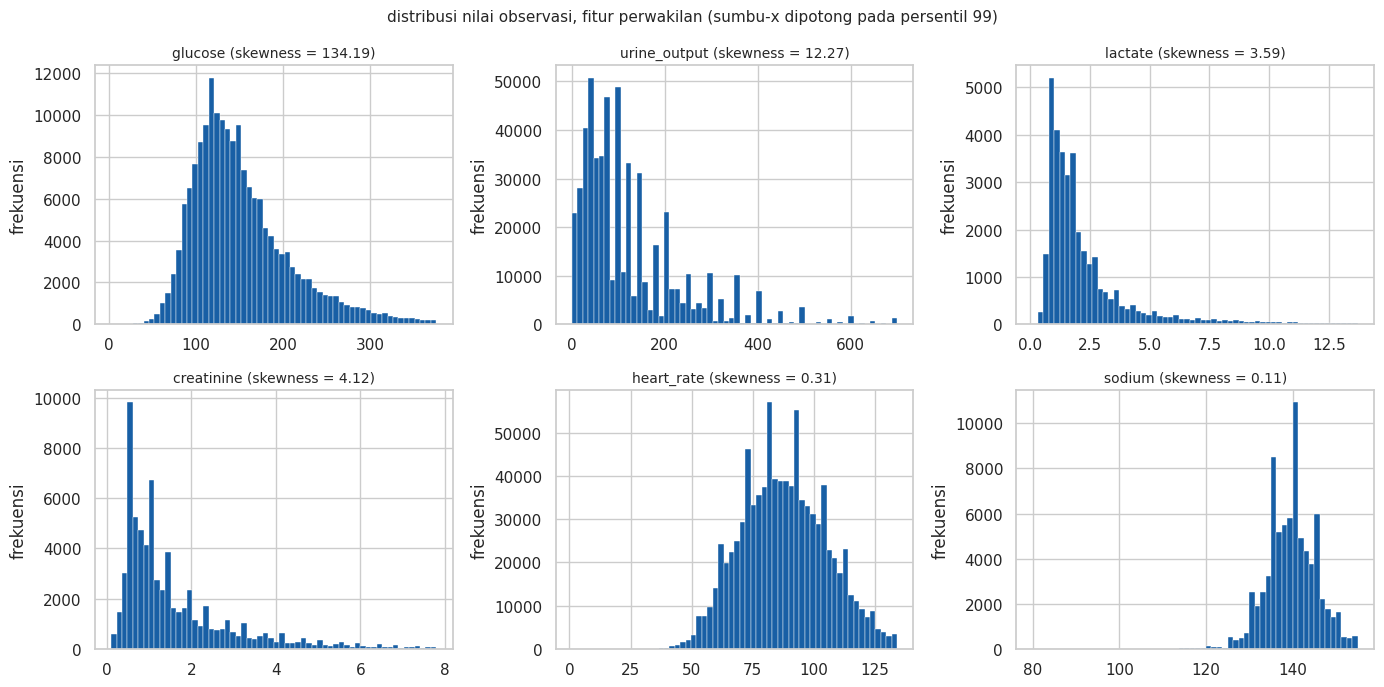

In [ ]:
# cell 3C: uji normalitas distribusi observasi per fitur.
# Hasil dipakai sebagai analisis eksploratif bentuk distribusi fitur
# dan dasar pemilihan metode uji statistik pada seleksi fitur (Cell 3D).

# Digunakan uji D'Agostino-Pearson karena mengevaluasi normalitas
# dari kombinasi skewness dan kurtosis, dan membutuhkan ukuran
# sampel yang memadai agar valid.

# Tahapan uji:
#   1. observasi seluruh pasien dipool menjadi satu distribusi
#   2. hitung skewness
#   3. hitung kurtosis
#   4. gabungkan menjadi statistik K-kuadrat
#   5. hitung p-value

# Catatan metodologis:
#   - Observasi intra-pasien tidak i.i.d. (repeated measurements per
#     stay), sehingga uji ini menggambarkan bentuk distribusi pooled,
#     bukan inferensi formal.
#   - Pada n besar, p-value sangat sensitif dan cenderung menolak
#     normalitas untuk hampir semua fitur. Pada data ini penolakan
#     tersebut konsisten dengan skewness yang ekstrem (lihat kolom
#     skewness), sehingga kesimpulan
#     non-normal tetap kuat.
#   - Kolom 'normal' didasarkan pada p-value D'Agostino-Pearson, yang
#     sudah mempertimbangkan skewness dan kurtosis sekaligus. Kolom
#     skewness ditampilkan sebagai deskripsi arah dan derajat
#     kemiringan, bukan kriteria penentu.

from scipy import stats

results = []
for col in FEATURE_COLS:
    vals = df[col].dropna().values
    if len(vals) < 20:
        results.append({'fitur': col, 'n': len(vals), 'k2': None,
                         'p_value': None, 'skewness': None, 'normal': False})
        continue
    k2, p = stats.normaltest(vals)
    results.append({
        'fitur'   : col,
        'n'       : len(vals),
        'k2'      : k2,
        'p_value' : p,
        'skewness': float(pd.Series(vals).skew()),
        'normal'  : p > 0.05,
    })

df_norm = (pd.DataFrame(results).set_index('fitur')
             .sort_values('skewness', key=lambda s: s.abs(), ascending=False))

df_show = df_norm.copy()
df_show['p_value'] = df_show['p_value'].apply(
    lambda v: '< 0.05' if pd.notna(v) and v < 0.05 else v)

print(df_show.round({'k2': 1, 'skewness': 3}).to_string())
print(f"\nNormal: {df_norm['normal'].sum()}/{len(FEATURE_COLS)} | "
      f"Non-normal: {(~df_norm['normal']).sum()}/{len(FEATURE_COLS)}")

#fitur perwakilan untuk visualisasi
# Dipilih mencakup rentang derajat kemiringan: dari sangat miring
# (glucose) hingga mendekati simetris (sodium) — yang seluruhnya
# tetap menolak normalitas.
demo_cols = [c for c in ['glucose', 'urine_output', 'lactate',
                         'creatinine', 'heart_rate', 'sodium']
             if c in FEATURE_COLS]

# histogram
# Sumbu-x dipotong pada persentil 99 hanya untuk keterbacaan tampilan
# (data ber-skew ekstrem membuat outlier meregangkan sumbu); uji
# normalitas di atas tetap memakai seluruh observasi.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), demo_cols):
    vals = df[col].dropna().values
    skew = df_norm.loc[col, 'skewness']
    x_max = np.percentile(vals, 99)
    ax.hist(vals[vals <= x_max], bins=60,
            color='#185FA5', edgecolor='white', linewidth=0.3)
    ax.set_title(f"{col} (skewness = {skew:.2f})", fontsize=10)
    ax.set_ylabel('frekuensi')
for ax in axes.flatten()[len(demo_cols):]:
    ax.set_visible(False)
fig.suptitle('distribusi nilai observasi, fitur perwakilan '
             '(sumbu-x dipotong pada persentil 99)', fontsize=11)
plt.tight_layout()
plt.show()


df_fs (post pre-syok censoring): 722,530 rows | balanced sample: 100,376 rows (50,188 syok + 50,188 non-syok)

Kruskal-Wallis eta2 per fitur:
                eta2 p_value
lactate       0.1613  < 0.05
baseexcess    0.1062  < 0.05
bicarbonate   0.1004  < 0.05
aniongap      0.0990  < 0.05
totalco2      0.0933  < 0.05
bilirubin     0.0882  < 0.05
inr           0.0798  < 0.05
pt            0.0781  < 0.05
creatinine    0.0538  < 0.05
sbp           0.0512  < 0.05
map           0.0474  < 0.05
urine_output  0.0463  < 0.05
ph            0.0454  < 0.05
platelet      0.0394  < 0.05
dbp           0.0366  < 0.05
ast           0.0355  < 0.05
fio2          0.0355  < 0.05
ptt           0.0332  < 0.05
bun           0.0271  < 0.05
rdw           0.0250  < 0.05
pco2          0.0202  < 0.05
wbc           0.0195  < 0.05
sodium        0.0179  < 0.05
potassium     0.0138  < 0.05
temperature   0.0138  < 0.05
alp           0.0130  < 0.05
pf_ratio      0.0093  < 0.05
calcium       0.0093  < 0.05
heart_rate    0.0

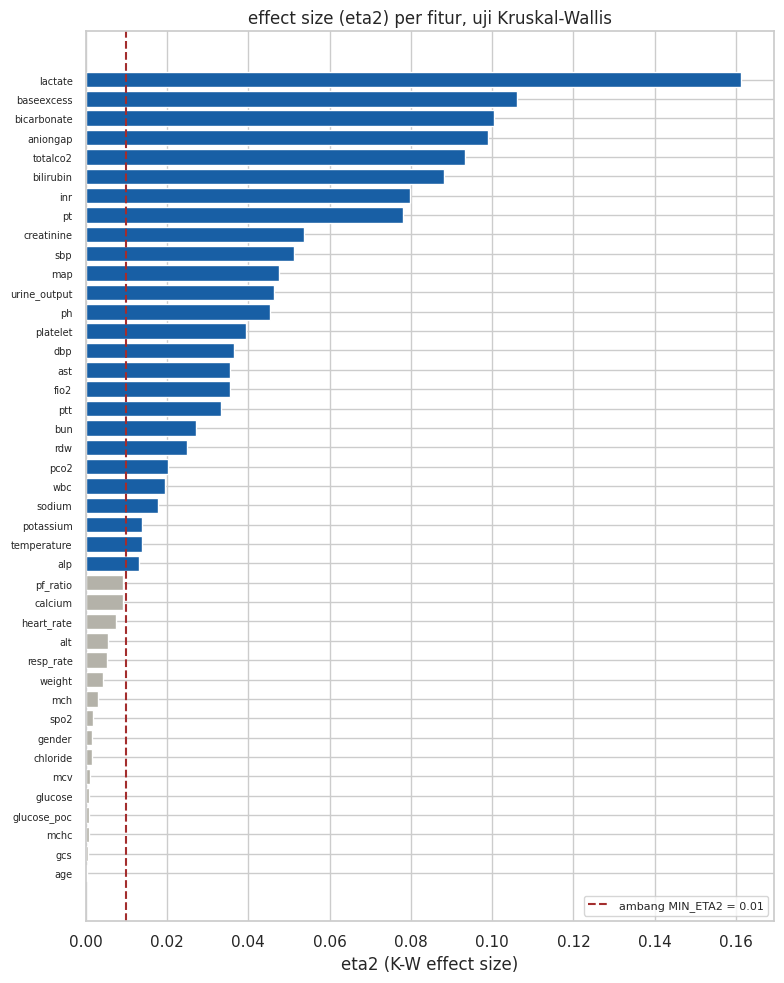

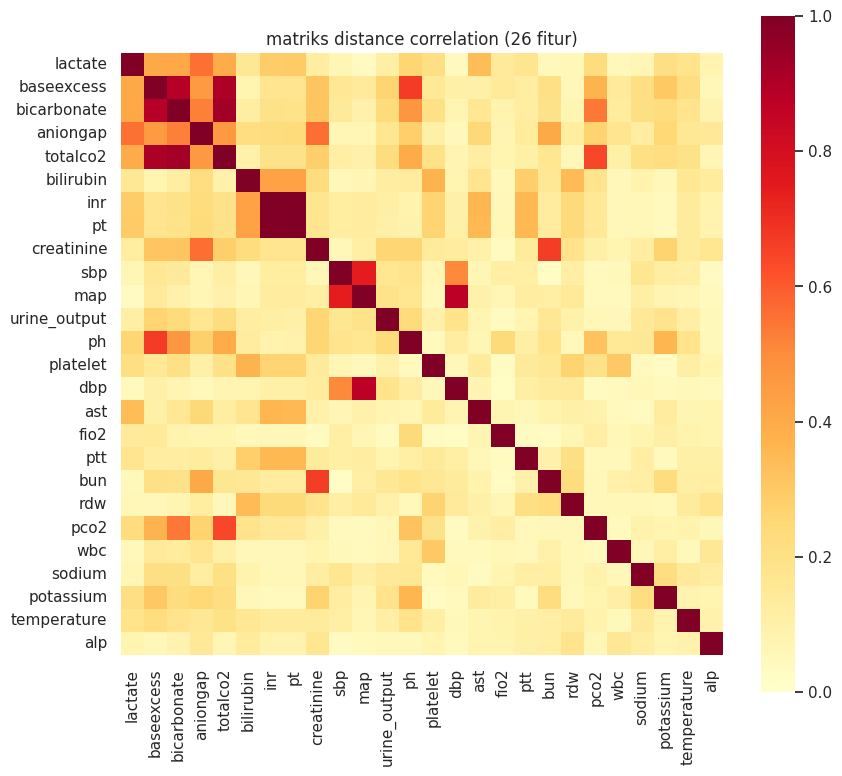

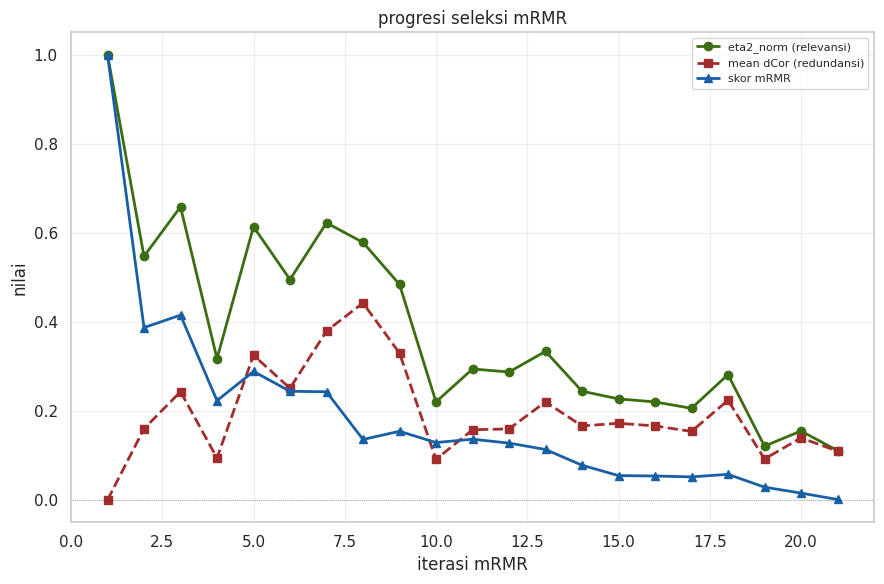

In [ ]:
# cell 3D "feature selection"

# alur:
# step 0 -> window pre-syok, kemudian balancing sample syok vs non-syok
# step 1 -> kruskal-wallis H test, kemudian effect size eta^2
# step 2 -> koreksi benjamini-hochberg FDR (dengan q = 0.05)
# step 3 ->

#   Step 0 : pre-shock censoring + balanced sampling shock vs non-shock
#   Step 1 : Kruskal-Wallis H test -> effect size eta2 = (H-k+1)/(N-k)
#   Step 2 : Benjamini-Hochberg FDR control (q=0.05)
#   Step 2B: filter minimum effect size (eta2 >= MIN_ETA2)
#   Step 3 : distance correlation pairwise pada FEATURE_COLS_KW
#   Step 4 : greedy mRMR, score = eta2_norm - mean_dCor(f, S),
#            berhenti saat score <= 0 (natural stop)
#
# Referensi:
#   Peng H, Long F, Ding C (2005). Feature selection based on mutual
#     information: criteria of max-dependency, max-relevance, and
#     min-redundancy. IEEE TPAMI 27(8):1226-1238.
#     https://doi.org/10.1109/TPAMI.2005.159
#   Szekely GJ, Rizzo ML, Bakirov NK (2007). Measuring and testing
#     dependence by correlation of distances. Ann Stat 35(6):2769-2794.
#     https://doi.org/10.1214/009053607000000505
#   Benjamini Y, Hochberg Y (1995). Controlling the false discovery
#     rate. J R Stat Soc B 57(1):289-300.
#   Cohen J (1988). Statistical Power Analysis for the Behavioral
#     Sciences. 2nd ed. Lawrence Erlbaum. (benchmark effect size
#     eta-squared; lihat Step 2B)


# step 0 -> window pre-syok, lalu balancing sample syok vs non-syok

# window pre-syok = hanya baris sblm onset yang dipakai [0, T-1]
# balancing sample agar jumlah baris syok dan non-syok seimbang

df_fs = df[
    (df['has_shock'] == 0) |
    (df['hr'] < df['t_shock_onset'])
].copy()

np.random.seed(RANDOM_SEED) # 42
shock_rows    = df_fs[df_fs['has_shock'] == 1]
nonshock_rows = df_fs[df_fs['has_shock'] == 0]

n_balance = min(len(shock_rows), len(nonshock_rows))

shock_sample = shock_rows.sample(n=n_balance, random_state=RANDOM_SEED)
nonshock_sample = nonshock_rows.sample(n=n_balance, random_state=RANDOM_SEED)

df_bal = pd.concat([shock_sample, nonshock_sample], ignore_index=True)

print(f"df_fs (post pre-syok censoring): {len(df_fs):,} rows | "
      f"balanced sample: {len(df_bal):,} rows "
      f"({n_balance:,} syok + {n_balance:,} non-syok)")

# step 1 -> Kruskal-Wallis H test, eta^2 effect size

eta2_dict, p_dict = {}, {}

# looping setiap fitur yang ada di array
for col in FEATURE_COLS:

    s = df_bal.loc[df_bal['has_shock'] == 1, col].dropna().values
    n = df_bal.loc[df_bal['has_shock'] == 0, col].dropna().values

    # if len(s) < 10 or len(n) < 10:
    #     eta2_dict[col] = 0.0
    #     p_dict[col]    = 1.0
    #     continue

    H, pval = stats.kruskal(s, n) # fungsi kruskal, return H dan p-value

    N = len(s) + len(n)   # total seluruh sampel dari kedua kelompok
    k = 2                 # jumlah kelompok (syok &non-syok)

    eta2 = max(0.0, (H - k + 1) / (N - k))

    eta2_dict[col] = eta2
    p_dict[col]    = pval
#end loop

eta2_series = pd.Series(eta2_dict).sort_values(ascending=False)

def fmt_p(p):
    return '< 0.05' if p < 0.05 else f'{p:.4f}'

# urutan p-value disejajarkan dgn index eta kuadrat
p_top = pd.Series(p_dict).reindex(eta2_series.index)

print(f"\nKruskal-Wallis eta2 per fitur:")
print(pd.DataFrame({
    'eta2'   : eta2_series.round(4),
    'p_value': p_top.apply(fmt_p),
}).to_string())

# step 2A -> Benjamini-Hochberg False Discovery Rate (FDR)
p_vals = pd.Series(p_dict)

reject_bh, _, _, _ = multipletests(p_vals.values, alpha=0.05, method='fdr_bh')

bh_sig  = p_vals.index[reject_bh].tolist() #untuk fitur yang lolos koreksi BH-FDR
bh_drop = [f for f in FEATURE_COLS if f not in bh_sig] #fitur yang di-drop

print(f"\nBH-FDR q=0.05: {len(bh_sig)} signifikan, {len(bh_drop)} di-drop -> {sorted(bh_drop, key=lambda f: p_dict[f], reverse=True)}")

# step 2B -> filter minimum effect size
# ambang minimum eta^2 = 0.01 (small-effect Cohen)

# effect size menurut Cohen (1988) dalam penelitian statistik:
# a) 0.01 = small
# b) 0.06 = medium
# c) 0.14 = large

MIN_ETA2 = 0.01 # angka 0.01 berdasarkan ambang small-effect Cohen

# fitur dengan effect size dibawah threshold small dianggap
# terlalu lemah untuk dipertahankan sebagai kandidat seleksi

dropped_low = [f for f in bh_sig if eta2_dict[f] < MIN_ETA2]
dropped_low_sorted = sorted(dropped_low, key=lambda f: eta2_dict[f]) #fitur diurutkan dari yang terlemah

print(f"Min eta2 < {MIN_ETA2}: drop {len(dropped_low)} -> {dropped_low_sorted}")

# set kandidat untuk step dCor dan mRMR
FEATURE_COLS_KW = [f for f in bh_sig if f not in dropped_low]

print(f"FEATURE_COLS_KW: {len(FEATURE_COLS_KW)} fitur untuk dCor + mRMR")

# step 3 -> distance correlation pairwise
print(f"\ndCor pairwise ({len(FEATURE_COLS_KW)} fitur, "
      f"{len(FEATURE_COLS_KW)*(len(FEATURE_COLS_KW)-1)//2} pairs)...")

dcor_mat = np.eye(len(FEATURE_COLS_KW)) # matriks fitur tersaring

df_bal_sample = df_bal

for i, f1 in enumerate(FEATURE_COLS_KW):
    if (i + 1) % 10 == 0 or (i + 1) == len(FEATURE_COLS_KW):
        print(f"  {i+1}/{len(FEATURE_COLS_KW)}")
    for j, f2 in enumerate(FEATURE_COLS_KW):
        if j <= i:
            continue

        s12 = df_bal_sample[[f1, f2]].dropna()  # diambil irisan nilai kedua fitur
                                                # drop jika salah satu nilai fiturnya NULL

        # penghitungan dCor antara kedua fitur
        d = dcor.distance_correlation(s12[f1].values, s12[f2].values)

        dcor_mat[i, j] = d
        dcor_mat[j, i] = d

#end loop

# ubah matriks dCor menjadi tabel berlabel fitur
dcor_df = pd.DataFrame(dcor_mat, index=FEATURE_COLS_KW, columns=FEATURE_COLS_KW)

# misal:
# dcor_mat =
# [[1.00, 0.82],
#  [0.82, 1.00]]

# -->> maka FEATURE_COLS_KW: ['lactate', 'creatinine']

# rata-rata nilai hubungan antar fitur(tanpa diagonal)
off_diag_mean = dcor_mat[np.triu_indices_from(dcor_mat, k=1)].mean()
print(f"dCor mean off-diagonal: {off_diag_mean:.4f}")

# normalisasi eta^2
eta2_max  = max(eta2_dict[f] for f in FEATURE_COLS_KW) # nilai eta^2 dijad
eta2_norm = {f: eta2_dict[f] / eta2_max for f in FEATURE_COLS_KW}
print(f"\nNormalisasi eta2: max={eta2_max:.5f} -> eta2_norm dalam [0, 1]")

# step 4 -> greedy mRMR (minimum redundancy, maximum relevance )

# relevansi = seberapa kuat fitur berkorelasi dengan label
# redundansi = seberapa berbeda fitur dari fitur yang sudah dipilih

print(f"\nmRMR greedy (stop saat score <= 0):")

selected    = []
remaining   = list(FEATURE_COLS_KW)
progression = []

best_first = max(remaining, key=lambda f: eta2_norm[f]) # simpan fitur dengan eta^2 terbesar
                                                        # ini sebagai iterasi pertama.

selected.append(best_first)
remaining.remove(best_first)


progression.append({
    'iter': 1, 'feat': best_first,
    'eta2_norm': eta2_norm[best_first],
    'mean_dcor': 0.0,
    'score': eta2_norm[best_first],
})
print(f"  [1] {best_first:20s} eta2={eta2_dict[best_first]:.4f} "
      f"eta2_norm={eta2_norm[best_first]:.4f}")


# S = set fitur yang sudah terpilih (remaining = sisa fitur)
# eta^2 norm = relevansi (yang sudah dinormalisasi )

while remaining:
    scores = {}
    for f in remaining:
        mean_dcor = np.mean([dcor_df.loc[f, s] for s in selected])

        #skor = eta^2 (norm) - mean dCor
        scores[f] = eta2_norm[f] - mean_dcor

    # dari semua kandidat, ambil yg skornya paling tinggi
    # fitur ini menjadi pemenang di iterasi ini
    best_f     =max(scores, key=scores.get)
    best_score = scores[best_f]

    # case:
    # jika skor terbaik <=0, stop iterasi
    # hal ini berarti berarti relevansi <= redundansi
    if best_score <= 0:
        print(f"  Stop: {len(selected)} fitur, next score "
              f"{best_score:.4f} <= 0 (natural stop)")
        break

    mean_dcor = np.mean([dcor_df.loc[best_f, s] for s in selected])
    selected.append(best_f)
    remaining.remove(best_f)

    progression.append({
        'iter': len(selected), 'feat': best_f,
        'eta2_norm': eta2_norm[best_f],
        'mean_dcor': mean_dcor,
        'score': best_score,
    })

    print(f"  [{len(selected)}] {best_f:20s} "
          f"eta2_norm={eta2_norm[best_f]:.4f} "
          f"mean_dCor={mean_dcor:.4f} score={best_score:.4f}")
#end loop

FEATURE_COLS_FINAL = selected[:]

prog_df = pd.DataFrame(progression)
print(f"\nFEATURE_COLS_FINAL: {len(FEATURE_COLS_FINAL)} fitur")
print(f"  {FEATURE_COLS_FINAL}")

# report per-kategori
CATEGORIES = {
    'vital'     : ['heart_rate','sbp','dbp','map',
                   'resp_rate','temperature','spo2'],
    'chemistry' : ['glucose','glucose_poc','aniongap','bun','creatinine',
                   'bicarbonate','calcium','chloride','sodium','potassium'],
    'CBC'       : ['hematocrit','hemoglobin','platelet','wbc','rdw',
                   'mcv','mch','mchc','rbc'],
    'koagulasi' : ['inr','pt','ptt'],
    'enzim'     : ['ast','alt','alp','bilirubin'],
    'ABG'       : ['lactate','ph','pco2','po2','baseexcess','fio2',
                   'totalco2','pf_ratio'],
    'GCS'       : ['gcs'],
    'urine'     : ['urine_output'],
    'static'    : ['age','gender','weight'],
}

print(f"\nfitur terpilih per-kategori:")
for cat, feats in CATEGORIES.items():
    picked = [f for f in feats if f in FEATURE_COLS_FINAL]
    if picked:
        print(f"  {cat:11s}: {len(picked)}/{len(feats)} -> {picked}")
    else:
        print(f"  {cat:11s}: 0/{len(feats)} -> -")

#gambar 1 -> KW + eta2
fig, ax = plt.subplots(figsize=(8, 10))
sig_features = [f for f in FEATURE_COLS if f in bh_sig]
eta2_sig = (pd.Series({f: eta2_dict[f] for f in sig_features})
              .sort_values(ascending=True))

#biru = lolos filter effect size, jadi kandidat mRMR
#abu  = gugur di filter MIN_ETA2 (effect size di bawah ambang)
colors = ['#185FA5' if f in FEATURE_COLS_KW else '#B4B2A9'
          for f in eta2_sig.index]

ax.barh(eta2_sig.index, eta2_sig.values, color=colors)
ax.axvline(MIN_ETA2, color='#A32D2D', linestyle='--', linewidth=1.5,
           label=f"ambang MIN_ETA2 = {MIN_ETA2}")
ax.set_xlabel('eta2 (K-W effect size)')
ax.set_title('effect size (eta2) per fitur, uji Kruskal-Wallis')
ax.legend(loc='lower right', fontsize=8)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig('fig_kw_eta2.png', dpi=150, bbox_inches='tight')
plt.show()

#gambar 2: heatmap matrix dCor
fig, ax = plt.subplots(figsize=(9, 8))
sorted_features = sorted(FEATURE_COLS_KW, key=lambda f: -eta2_dict[f])
dcor_sorted = dcor_df.loc[sorted_features, sorted_features]
sns.heatmap(dcor_sorted, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            cbar=True, square=True,
            xticklabels=sorted_features, yticklabels=sorted_features)
ax.set_title(f'matriks distance correlation ({len(FEATURE_COLS_KW)} fitur)')
plt.tight_layout()
plt.savefig('fig_dcor_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

#gambar 3 -> progresi mRMR
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(prog_df['iter'], prog_df['eta2_norm'],
        marker='o', color='#3B6D11', label='eta2_norm (relevansi)', linewidth=2)
ax.plot(prog_df['iter'], prog_df['mean_dcor'],
        marker='s', color='#A32D2D', linestyle='--',
        label='mean dCor (redundansi)', linewidth=2)
ax.plot(prog_df['iter'], prog_df['score'],
        marker='^', color='#185FA5', label='skor mRMR', linewidth=2)
ax.axhline(0, color='black', linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_xlabel('iterasi mRMR')
ax.set_ylabel('nilai')
ax.set_title('progresi seleksi mRMR')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_mrmr_progression.png', dpi=150, bbox_inches='tight')
plt.show()

# cell 4: imputasi fitur

In [ ]:
# cell 4A: list fitur per-kategori yg disiapkan utk imputasi

_VITAL_REF = ['heart_rate', 'sbp', 'dbp', 'map',
              'resp_rate', 'temperature', 'spo2']

VITAL_FEATS = [f for f in _VITAL_REF       if f in FEATURE_COLS_FINAL]
URINE_FEATS = [f for f in ['urine_output'] if f in FEATURE_COLS_FINAL]
LAB_FEATS   = [f for f in FEATURE_COLS_FINAL
               if f not in VITAL_FEATS + URINE_FEATS]

print(f"kategori ({len(FEATURE_COLS_FINAL)} fitur) :")
print(f"vital = {VITAL_FEATS}")
print(f"lab   = {LAB_FEATS}")
print(f"urin  = {URINE_FEATS}")


kategori (21 fitur) :
vital = ['sbp', 'dbp', 'map']
lab   = ['lactate', 'bilirubin', 'baseexcess', 'aniongap', 'inr', 'bicarbonate', 'totalco2', 'pt', 'fio2', 'creatinine', 'platelet', 'ast', 'ptt', 'ph', 'wbc', 'rdw', 'sodium']
urin  = ['urine_output']


In [ ]:
# cell 4B: imputasi fitur terpilih

# pemilihan metode imputasi didasarkan pada karakteristik kategori fitur
# untuk vital: interpolasi linear -> ffill -> bfill per pasien
# karena sifat vital yang kontinu halus, maka gap diantara dua nilai pakai interpolasi
# jam-jam awal untuk fitur vital yang belum ada datanya ditangani dengan bfill,
# d

# Strategi imputasi disesuaikan dengan sifat tiap jenis fitur:
#   - Vitals : interpolasi linear -> ffill -> bfill per stay.
#              Vital sign adalah sinyal kontinu yang berubah
#              bertahap, sehingga interpolasi antar pengukuran
#              masuk akal.
#   - Labs + urine_output : ffill -> bfill per stay.
#              Nilai lab bersifat bertahap (step), bukan kontinu.
#              urine_output mengikuti strategi yang sama: pada
#              tahap ekstraksi (M5) urine sudah diagregasi sebagai
#              total per jam, sehingga nilainya sudah berada pada
#              resolusi per jam. Pendekatan distribusi volume yang
#              umum pada literatur AKI tidak diperlukan karena
#              agregasi per jam telah dilakukan di tahap query.
#              Jam tanpa pencatatan urine diperlakukan sebagai
#              missing biasa, identik dengan lab.

_VITAL_REF  = ['heart_rate', 'sbp', 'dbp', 'map',
               'resp_rate', 'temperature', 'spo2']
VITAL_FEATS = [f for f in _VITAL_REF if f in FEATURE_COLS_FINAL]

LAB_FEATS   = [f for f in FEATURE_COLS_FINAL if f not in VITAL_FEATS]

nan_pre = df[FEATURE_COLS_FINAL].isna().sum().sum()
print(f"Pre-imputasi: {df['stay_id'].nunique():,} stays | "
      f"{len(df):,} rows | {nan_pre:,} NaN")

for col in VITAL_FEATS:
    df[col] = df.groupby('stay_id')[col].transform(
        lambda x: x.interpolate(method='linear',
                                limit_direction='both').ffill().bfill()
    )

for col in LAB_FEATS:
    df[col] = df.groupby('stay_id')[col].transform(
        lambda x: x.ffill().bfill()
    )

# drop stay yang memiliki fitur tertentu dengan NaN di semua jam

# Stay yang tidak pernah punya pengukuran untuk suatu fitur tidak
# dapat diimputasi (ffill/bfill/interpolasi semuanya butuh minimal
# satu nilai observasi). Stay seperti ini di-drop

nan_remaining = df[FEATURE_COLS_FINAL].isna().sum()
nan_remaining = nan_remaining[nan_remaining > 0]
if len(nan_remaining) > 0:
    drop_stays = set()
    for col in nan_remaining.index:
        drop_stays |= set(df.loc[df[col].isna(), 'stay_id'].unique())
    df = df[~df['stay_id'].isin(drop_stays)].copy()

    print(f"drop {len(drop_stays):,} stay dengan permanent NaN "
          f"(fitur tanpa pengukuran sama sekali)")

n_stays = df['stay_id'].nunique()
n_shock = int(df.groupby('stay_id')['has_shock'].first().sum())
print(f"post-imputasi: {n_stays:,} stay "
      f"({n_shock:,} syok, {n_stays-n_shock:,} non-syok) | "
      f"{len(df):,} row")

Pre-imputasi: 4,887 stays | 936,905 rows | 15,352,193 NaN
drop 261 stay dengan permanent NaN (fitur tanpa pengukuran sama sekali)
post-imputasi: 4,626 stay (1,046 syok, 3,580 non-syok) | 906,989 row


# cell 5: split & scalling

In [ ]:
# cell 5A: split train/val/test per stay

# split per stay_id, proporsi shock harus seimbang antar 3 dataset

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# label perlu dibedakan menjadi 2:
# 1. stay yang sepanjang ICU berkembang menjadi syok (label 1), dan
# 2. sepanjang ICU tidak berkembang menjadi syok (label 0)
stay_label = df.groupby('stay_id')['has_shock'].first().astype(int)

train_stays, val_stays, test_stays = [], [], []
for label_value in [0, 1]:
    stays = stay_label.index[stay_label == label_value].to_numpy()
    np.random.RandomState(RANDOM_SEED).shuffle(stays)

    n_train = int(len(stays) * TRAIN_FRAC)
    n_val   = int(len(stays) * VAL_FRAC)
    train_stays.extend(stays[:n_train])
    val_stays.extend(stays[n_train:n_train + n_val])
    test_stays.extend(stays[n_train + n_val:])

train_stays = np.array(train_stays)
val_stays   = np.array(val_stays)
test_stays  = np.array(test_stays)

# total stay yang displit
total = df['stay_id'].nunique()
for name, stays in [('train', train_stays),
                    ('val',   val_stays),
                    ('test',  test_stays)]:
    n       = len(stays)
    n_shock = int(stay_label.loc[stays].sum())
    print(f"  {name:6}: {n:,} stays ({100*n/total:.1f}%) | "
          f"{n_shock:,} shock, {n-n_shock:,} non-shock "
          f"({100*n_shock/n:.1f}% shock)")

  train : 3,238 stays (70.0%) | 732 shock, 2,506 non-shock (22.6% shock)
  val   : 693 stays (15.0%) | 156 shock, 537 non-shock (22.5% shock)
  test  : 695 stays (15.0%) | 158 shock, 537 non-shock (22.7% shock)


In [ ]:
# Cell 5A: fit dari train, transform semua

scaler = StandardScaler()
scaler.fit(df.loc[df['stay_id'].isin(train_stays), FEATURE_COLS_FINAL])
df[FEATURE_COLS_FINAL] = scaler.transform(df[FEATURE_COLS_FINAL])

print(f"scaling selesai | fit {len(train_stays):,} train stays | "
      f"transform {len(df):,} row")

scaling selesai | fit 3,238 train stays | transform 906,989 row


In [ ]:
# cell 5B: framing penelitian

# Per stay menghasilkan examples (sequence_0_to_T, label, weight):
#   Shock     : T pada [0, onset-1], diambil merata maks K_SHOCK titik
#   Non-shock : T diambil merata maks K_NONSHOCK titik dari LOS

# Temporal weight (shock saja): w = exp(-lambda * (onset - T - 1))
#   T = onset-1 -> w = 1.0 (maksimum); T jauh dari onset -> w -> 0.
#   Non-shock: w = 1.0.

# Catatan: titik T diambil merata (np.linspace), bukan acak,
# sehingga pembentukan example bersifat deterministik.

K_SHOCK    = 20
K_NONSHOCK = 15
LAMBDA_TW  = 0.05


def build_examples(df, stay_ids, feature_cols, k_shock, k_nonshock, lambda_tw):

    """Bangun list example Framing B. Return list of dict."""
    examples = []
    for stay_id in stay_ids:
        stay_df  = df[df['stay_id'] == stay_id].sort_values('hr')
        is_shock = int(stay_df['has_shock'].iloc[0]) == 1

        if is_shock:
            onset     = int(stay_df['t_shock_onset'].iloc[0])
            valid_hrs = stay_df.loc[stay_df['hr'] < onset, 'hr'].values
            if len(valid_hrs) == 0:
                continue
            k = k_shock
        else:
            valid_hrs = stay_df['hr'].values
            k = k_nonshock

        # ambil maks k titik T, disebar merata sepanjang rentang
        if len(valid_hrs) > k:
            idx       = np.linspace(0, len(valid_hrs) - 1, k).astype(int)
            valid_hrs = valid_hrs[idx]

        for T in valid_hrs:
            seq    = stay_df.loc[stay_df['hr'] <= T, feature_cols].values
            weight = (float(np.exp(-lambda_tw * (onset - T - 1)))
                      if is_shock else 1.0)
            examples.append({
                'sequence': torch.tensor(seq, dtype=torch.float32),
                'label'   : torch.tensor(1.0 if is_shock else 0.0,
                                         dtype=torch.float32),
                'weight'  : weight,
                'stay_id' : stay_id,
                'T'       : int(T),
            })
    return examples


# build per-split
train_examples = build_examples(df, train_stays, FEATURE_COLS_FINAL,
                                K_SHOCK, K_NONSHOCK, LAMBDA_TW)
val_examples   = build_examples(df, val_stays,   FEATURE_COLS_FINAL,
                                K_SHOCK, K_NONSHOCK, LAMBDA_TW)
test_examples  = build_examples(df, test_stays,  FEATURE_COLS_FINAL,
                                K_SHOCK, K_NONSHOCK, LAMBDA_TW)

# output
for name, ex in [('train', train_examples),
                 ('val',   val_examples),
                 ('test',  test_examples)]:
    n_shock = sum(1 for e in ex if e['label'].item() == 1)
    print(f"  {name:6}: {len(ex):,} examples "
          f"({n_shock:,} syok, {len(ex)-n_shock:,} non-syok)")

  train : 47,439 examples (9,894 syok, 37,545 non-syok)
  val   : 9,976 examples (1,931 syok, 8,045 non-syok)
  test  : 10,133 examples (2,100 syok, 8,033 non-syok)


# cell 6: modelling

In [ ]:
# cell 6: framework arsitektur model DL

# 3 model DL yg dipilih:
# GRU (Gated Recurrent Unit) -> perwakilan RNN
# TCN (Temporal Convolutional Network) -> perwakilan CNN
# Transformer -> perwakilan attention

# Hyperparameter dipilih konservatif untuk cohort berukuran sedang,
# dengan mempertimbangkan keterbatasan komputasi:
#   hidden=32, dropout=0.4, weight_decay=1e-4.
# Regularisasi berlapis dipakai agar pelatihan stabil tanpa
# hyperparameter search.

# Class imbalance ditangani via pos_weight pada BCEWithLogitsLoss.
# POS_WEIGHT dihitung dari train stays saja untuk mencegah leakage.

# train_examples dan val_examples di-pre-move ke device sebelum
# training loop untuk menghilangkan overhead transfer CPU ke GPU
# per-iterasi. test_examples tetap di CPU agar kompatibel dengan
# Captum ShapleyValueSampling (Cell 9) yang memerlukan konversi numpy.

import torch.nn.functional as F

# Performa dititikberatkan pada AUPRC. Overfitting ditandai oleh
# performa tinggi pada data training tetapi turun pada data validation.

# hyperparameter
HIDDEN_SIZE        = 32
NUM_LAYERS         = 2      # dipakai GRU dan TCN; Transformer pakai N_LAYERS_TF sendiri
DROPOUT            = 0.4
LR                 = 5e-4
WEIGHT_DECAY       = 1e-4
ACCUMULATION_STEPS = 32
MAX_EPOCHS         = 30
PATIENCE           = 7
MIN_WEIGHT         = 1e-3
GRAD_CLIP_NORM     = 1.0
OVERFIT_GAP        = 0.15
MONITOR_N_SHOCK    = 500
MONITOR_N_NONSHOCK = 1500

# ── Class imbalance handling — train only (anti-leakage) ──
train_stay_labels = df.loc[df['stay_id'].isin(train_stays)] \
    .groupby('stay_id')['has_shock'].first()
POS_WEIGHT = float((train_stay_labels == 0).sum() /
                   (train_stay_labels == 1).sum())
print(f"POS_WEIGHT (train only): {POS_WEIGHT:.3f}")

# ── Pre-move train + val examples ke device untuk efisiensi training ──
# test_examples tetap di CPU karena Cell 9 (Captum) memerlukan
# konversi numpy.
def move_examples_to_device(examples, device):
    """Pre-move sequence dan label tensors ke device. Modify in-place."""
    for ex in examples:
        ex['sequence'] = ex['sequence'].to(device)
        ex['label']    = ex['label'].to(device)
    return examples

print(f"Pre-moving train + val examples to {device}...")
train_examples = move_examples_to_device(train_examples, device)
val_examples   = move_examples_to_device(val_examples,   device)
gc.collect()   # release referensi CPU

if device.type == 'cuda':
    mem_gb = torch.cuda.memory_allocated() / 1e9
    print(f"  GPU memory allocated: {mem_gb:.2f} GB")
print(f"  test_examples kept on CPU (Captum compatibility)")

# ── Pre-split train examples by label untuk stratified monitor ──
_train_shock    = [e for e in train_examples if e['label'].item() == 1]
_train_nonshock = [e for e in train_examples if e['label'].item() == 0]
print(f"Train shock examples: {len(_train_shock):,} | "
      f"non-shock: {len(_train_nonshock):,}")


def evaluate_model(model, examples, device):
    """AUPRC + AUROC pada list examples.

    Asumsi: examples sudah di device target (pre-moved di Cell 6 setup).
    Kalau dipanggil dengan test_examples (CPU), .to(device) idempotent.
    """
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for ex in examples:
            seq = ex['sequence'].unsqueeze(0)
            if seq.device != device:
                seq = seq.to(device)
            probs.append(torch.sigmoid(model(seq)).item())
            labels.append(ex['label'].item())
    probs, labels = np.array(probs), np.array(labels)
    if len(np.unique(labels)) < 2:
        return {'auprc': 0.0, 'auroc': 0.5}
    return {
        'auprc': average_precision_score(labels, probs),
        'auroc': roc_auc_score(labels, probs),
    }


def train_auprc_stratified(model, device):
    """Train AUPRC pada stratified subsample (consistent ratio)."""
    sample = (random.sample(_train_shock, min(MONITOR_N_SHOCK, len(_train_shock)))
              + random.sample(_train_nonshock,
                              min(MONITOR_N_NONSHOCK, len(_train_nonshock))))
    return evaluate_model(model, sample, device)['auprc']


def train_model(model, name, train_examples, val_examples,
                pos_weight, device,
                lr=LR, weight_decay=WEIGHT_DECAY,
                max_epochs=MAX_EPOCHS, patience=PATIENCE,
                accumulation=ACCUMULATION_STEPS,
                min_weight=MIN_WEIGHT, grad_clip=GRAD_CLIP_NORM,
                gap_threshold=OVERFIT_GAP):
    """Train Framing B examples dengan anti-overfit monitoring.

    Asumsi: train_examples dan val_examples sudah pre-moved ke device.
    """
    optimizer = torch.optim.Adam(model.parameters(),
                                  lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], device=device),
        reduction='mean')

    best_auprc, best_epoch, no_improve = -1.0, 0, 0
    best_state, history = None, []

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} | params={n_params:,}")
    print(f"{'Ep':>3} {'tr_loss':>9} {'tr_apr':>8} {'va_apr':>8} "
          f"{'gap':>7} {'va_auc':>8} {'lr':>9}")
    print("─" * 60)

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        epoch_loss, n_processed = 0.0, 0

        epoch_examples = train_examples.copy()
        random.shuffle(epoch_examples)

        for ex in epoch_examples:
            if ex['weight'] < min_weight:
                continue

            seq   = ex['sequence'].unsqueeze(0)
            label = ex['label'].unsqueeze(0)
            logit = model(seq)
            loss  = criterion(logit.unsqueeze(0), label)
            loss  = loss * ex['weight'] / accumulation
            loss.backward()

            epoch_loss   += loss.item() * accumulation
            n_processed  += 1

            if n_processed % accumulation == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(),
                                                max_norm=grad_clip)
                optimizer.step()
                optimizer.zero_grad()

        if n_processed % accumulation != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(),
                                            max_norm=grad_clip)
            optimizer.step()
            optimizer.zero_grad()

        avg_loss    = epoch_loss / max(n_processed, 1)
        val_metrics = evaluate_model(model, val_examples, device)
        tr_auprc    = train_auprc_stratified(model, device)
        gap         = tr_auprc - val_metrics['auprc']

        scheduler.step(val_metrics['auprc'])
        current_lr = optimizer.param_groups[0]['lr']

        history.append({
            'epoch'   : epoch,
            'tr_loss' : avg_loss,
            'tr_auprc': tr_auprc,
            'val_auprc': val_metrics['auprc'],
            'val_auroc': val_metrics['auroc'],
            'gap'     : gap,
            'lr'      : current_lr,
        })

        flag = ''

        # epoch terbaik: AUPRC validation lebih tinggi dari best
        # sebelumnya, ditandai dengan "*"
        if val_metrics['auprc'] > best_auprc:
            best_auprc, best_epoch = val_metrics['auprc'], epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
            flag = ' *'
        else:
            no_improve += 1

        if gap > gap_threshold:
            flag += ' [OVERFIT]'

        print(f"{epoch:>3} {avg_loss:>9.4f} {tr_auprc:>8.4f} "
              f"{val_metrics['auprc']:>8.4f} {gap:>7.3f} "
              f"{val_metrics['auroc']:>8.4f} {current_lr:>9.6f}{flag}")

        if no_improve >= patience:
            print(f"\nEarly stop (best AUPRC={best_auprc:.4f} "
                  f"@ epoch {best_epoch})")
            break

        gc.collect()
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return best_state, history, best_auprc, best_epoch

POS_WEIGHT (train only): 3.423
Pre-moving train + val examples to cuda...
  GPU memory allocated: 0.43 GB
  test_examples kept on CPU (Captum compatibility)
Train shock examples: 9,894 | non-shock: 37,545


In [ ]:
# cell 6A "training GRU"

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, num_layers,
                          dropout=dropout if num_layers > 1 else 0.0,
                          batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden, 1)
        self._init()

    def _init(self):
        for name, p in self.gru.named_parameters():
            if 'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name: nn.init.zeros_(p)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(self.dropout(h[-1].squeeze(0))).squeeze(0)


CKPT_PATH = f'{CHECKPOINT_DIR}/best_gru.pt'

model_gru = GRUModel(input_size=len(FEATURE_COLS_FINAL)).to(device) # model bekerja sepanjang fitur final yang terekstraksi

if os.path.exists(CKPT_PATH):
    ckpt_data = torch.load(CKPT_PATH, map_location=device)
    model_gru.load_state_dict(ckpt_data['state_dict'])
    gru_history = ckpt_data['history']
    gru_auprc   = ckpt_data['best_auprc']
    gru_epoch   = ckpt_data['best_epoch']
    print(f"GRU: loaded from {CKPT_PATH}")
    print(f"  Best epoch {gru_epoch} | val AUPRC {gru_auprc:.4f} | "
          f"history {len(gru_history)} epochs")
else:
    gru_state, gru_history, gru_auprc, gru_epoch = train_model(
        model_gru, 'GRU', train_examples, val_examples,
        pos_weight=POS_WEIGHT, device=device)
    model_gru.load_state_dict(gru_state)
    torch.save({
        'state_dict': gru_state,
        'history'   : gru_history,
        'best_auprc': gru_auprc,
        'best_epoch': gru_epoch,
    }, CKPT_PATH)
    print(f"GRU best: epoch {gru_epoch} | val AUPRC {gru_auprc:.4f}")
    print(f"Saved: {CKPT_PATH}")

GRU | params=11,649
 Ep   tr_loss   tr_apr   va_apr     gap   va_auc        lr
────────────────────────────────────────────────────────────
  1    0.4140   0.7731   0.6438   0.129   0.8633  0.000500 *
  2    0.3614   0.7898   0.6494   0.140   0.8656  0.000500 *
  3    0.3402   0.7908   0.6509   0.140   0.8673  0.000500 *
  4    0.3249   0.8175   0.6410   0.177   0.8628  0.000500 [OVERFIT]
  5    0.3076   0.8347   0.6339   0.201   0.8595  0.000500 [OVERFIT]
  6    0.2898   0.8169   0.6209   0.196   0.8586  0.000500 [OVERFIT]
  7    0.2791   0.8705   0.6221   0.248   0.8519  0.000250 [OVERFIT]
  8    0.2571   0.8601   0.5927   0.267   0.8448  0.000250 [OVERFIT]
  9    0.2509   0.8694   0.5910   0.278   0.8451  0.000250 [OVERFIT]
 10    0.2420   0.8799   0.5785   0.301   0.8370  0.000250 [OVERFIT]

Early stop (best AUPRC=0.6509 @ epoch 3)
GRU best: epoch 3 | val AUPRC 0.6509
Saved: /content/drive/MyDrive/skripsi_checkpoints/best_gru.pt


In [ ]:
# Cell 6B: TCN — causal dilated convolution.
# Bai S, Kolter JZ, Koltun V (2018). An Empirical Evaluation of Generic
# Convolutional and Recurrent Networks for Sequence Modeling.
# arXiv:1803.01271
#
# Receptive field 3 blocks dilation 1,2,4 = ~15 timesteps.
# Causal padding mencegah future leakage di Framing B prospective prediction.

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.pad  = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=0, dilation=dilation)
        nn.init.xavier_uniform_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)

    def forward(self, x):
        return self.conv(F.pad(x, (self.pad, 0)))


class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch,  out_ch, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.dropout = nn.Dropout(dropout)
        self.downsample = (nn.Conv1d(in_ch, out_ch, 1)
                           if in_ch != out_ch else None)
        if self.downsample is not None:
            nn.init.xavier_uniform_(self.downsample.weight)
            nn.init.zeros_(self.downsample.bias)

    def forward(self, x):
        out = self.dropout(F.relu(self.conv1(x)))
        out = self.dropout(F.relu(self.conv2(out)))
        res = x if self.downsample is None else self.downsample(x)
        return F.relu(out + res)


class TCNModel(nn.Module):
    def __init__(self, input_size, hidden=HIDDEN_SIZE,
                 kernel_size=3, dropout=DROPOUT):
        super().__init__()
        self.blocks = nn.Sequential(
            TCNBlock(input_size, hidden, kernel_size, 1, dropout),
            TCNBlock(hidden,     hidden, kernel_size, 2, dropout),
            TCNBlock(hidden,     hidden, kernel_size, 4, dropout),
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden, 1)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        x = x.transpose(1, 2)        # (1, T, F) → (1, F, T)
        x = self.blocks(x)
        last = x[:, :, -1].squeeze(0)
        return self.fc(self.dropout(last)).squeeze(0)


CKPT_PATH = f'{CHECKPOINT_DIR}/best_tcn.pt'
model_tcn = TCNModel(input_size=len(FEATURE_COLS_FINAL)).to(device)

if os.path.exists(CKPT_PATH):
    ckpt_data = torch.load(CKPT_PATH, map_location=device)
    model_tcn.load_state_dict(ckpt_data['state_dict'])
    tcn_history = ckpt_data['history']
    tcn_auprc = ckpt_data['best_auprc']
    tcn_epoch = ckpt_data['best_epoch']
    print(f"TCN: loaded from {CKPT_PATH}")
    print(f"  Best epoch {tcn_epoch} | val AUPRC {tcn_auprc:.4f} | "
          f"history {len(tcn_history)} epochs")

else:
    tcn_state, tcn_history, tcn_auprc, tcn_epoch = train_model(
        model_tcn, 'TCN', train_examples, val_examples,
        pos_weight=POS_WEIGHT, device=device)
    model_tcn.load_state_dict(tcn_state)
    torch.save({
        'state_dict': tcn_state,
        'history'   : tcn_history,
        'best_auprc': tcn_auprc,
        'best_epoch': tcn_epoch,
    }, CKPT_PATH)
    print(f"TCN best: epoch {tcn_epoch} | val AUPRC {tcn_auprc:.4f}")
    print(f"Saved: {CKPT_PATH}")

TCN | params=18,305
 Ep   tr_loss   tr_apr   va_apr     gap   va_auc        lr
────────────────────────────────────────────────────────────
  1    0.5020   0.7349   0.6238   0.111   0.8535  0.000500 *
  2    0.3923   0.7631   0.6487   0.114   0.8620  0.000500 *
  3    0.3711   0.7874   0.6507   0.137   0.8632  0.000500 *
  4    0.3489   0.8129   0.6612   0.152   0.8661  0.000500 * [OVERFIT]
  5    0.3357   0.8223   0.6571   0.165   0.8659  0.000500 [OVERFIT]
  6    0.3167   0.8154   0.6568   0.159   0.8608  0.000500 [OVERFIT]
  7    0.3078   0.8398   0.6572   0.183   0.8667  0.000500 [OVERFIT]
  8    0.2958   0.8486   0.6543   0.194   0.8666  0.000250 [OVERFIT]
  9    0.2751   0.8748   0.6408   0.234   0.8600  0.000250 [OVERFIT]
 10    0.2672   0.8526   0.6376   0.215   0.8628  0.000250 [OVERFIT]
 11    0.2575   0.8679   0.6316   0.236   0.8616  0.000250 [OVERFIT]

Early stop (best AUPRC=0.6612 @ epoch 4)
TCN best: epoch 4 | val AUPRC 0.6612
Saved: /content/drive/MyDrive/skripsi_checkp

In [ ]:
# Cell 6C: Transformer Encoder — pure self-attention.
# Vaswani A, et al. (2017). Attention is all you need.
# NeurIPS 2017. arXiv:1706.03762
#
# Konfigurasi conservative untuk moderate cohort (~1,100 shock cases):
#   d_model=32 (match HIDDEN_SIZE GRU/TCN)
#   n_heads=2 (32 / 2 = 16 dim per head)
#   n_encoder_layers=1
#   dim_feedforward=64 (2× d_model, standard ratio)
#
# Causal masking: setiap timestep T hanya attend ke 0..T, mencegah
# future leakage di Framing B growing window. Implementasi via
# upper triangular mask.
#
# Positional encoding: sinusoidal (Vaswani 2017), no learnable params.
# Pooling: mean across valid timesteps untuk classification head.
#
# Trade-off vs recurrent: Transformer self-attention O(T²) lebih lambat
# per epoch, tapi parallelizable. Risk overfit lebih tinggi di moderate
# cohort — mitigasi: dropout=0.4, 1 layer minimal.

import math

D_MODEL_TF      = 32
N_HEADS_TF      = 2
N_LAYERS_TF     = 1
DIM_FF_TF       = 64


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (1, T, d_model)
        return x + self.pe[:, :x.size(1), :]


class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=D_MODEL_TF,
                 n_heads=N_HEADS_TF, n_layers=N_LAYERS_TF,
                 dim_ff=DIM_FF_TF, dropout=DROPOUT):
        super().__init__()
        # Input projection: input_size → d_model
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = SinusoidalPositionalEncoding(d_model)

        # Encoder layer (causal via attention mask di forward)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            activation='relu',
            batch_first=True,
            norm_first=True,  # Pre-LN, lebih stabil di small data
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, n_layers)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_model, 1)
        self._init()

    def _init(self):
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        # x: (1, T, input_size)
        T = x.size(1)

        # Project ke d_model + positional encoding
        h = self.input_proj(x)                     # (1, T, d_model)
        h = self.pos_enc(h)

        # Causal mask: upper triangular (True = mask out future)
        # PyTorch convention: mask True = positions yang TIDAK boleh diakses
        causal_mask = torch.triu(
            torch.ones(T, T, dtype=torch.bool, device=x.device),
            diagonal=1
        )

        # Encoder
        h = self.encoder(h, mask=causal_mask)      # (1, T, d_model)

        # Mean pooling across timesteps
        pooled = h.mean(dim=1).squeeze(0)          # (d_model,)

        return self.fc(self.dropout(pooled)).squeeze(0)


CKPT_PATH = f'{CHECKPOINT_DIR}/best_transformer.pt'
model_transformer = TransformerModel(
    input_size=len(FEATURE_COLS_FINAL)
).to(device)

if os.path.exists(CKPT_PATH):
    ckpt_data = torch.load(CKPT_PATH, map_location=device)
    model_transformer.load_state_dict(ckpt_data['state_dict'])
    transformer_history = ckpt_data['history']
    transformer_auprc   = ckpt_data['best_auprc']
    transformer_epoch   = ckpt_data['best_epoch']
    print(f"Transformer: loaded from {CKPT_PATH}")
    print(f"  Best epoch {transformer_epoch} | "
          f"val AUPRC {transformer_auprc:.4f} | "
          f"history {len(transformer_history)} epochs")

else:
    (transformer_state, transformer_history,
     transformer_auprc, transformer_epoch) = train_model(
        model_transformer, 'Transformer', train_examples, val_examples,
        pos_weight=POS_WEIGHT, device=device)
    model_transformer.load_state_dict(transformer_state)
    torch.save({
        'state_dict': transformer_state,
        'history'   : transformer_history,
        'best_auprc': transformer_auprc,
        'best_epoch': transformer_epoch,
    }, CKPT_PATH)
    print(f"Transformer best: epoch {transformer_epoch} | "
          f"val AUPRC {transformer_auprc:.4f}")
    print(f"Saved: {CKPT_PATH}")

Transformer | params=9,281
 Ep   tr_loss   tr_apr   va_apr     gap   va_auc        lr
────────────────────────────────────────────────────────────
  1    0.4703   0.7653   0.6383   0.127   0.8553  0.000500 *
  2    0.3904   0.7666   0.6424   0.124   0.8590  0.000500 *
  3    0.3698   0.7924   0.6510   0.141   0.8649  0.000500 *
  4    0.3532   0.7834   0.6460   0.137   0.8583  0.000500
  5    0.3418   0.7994   0.6475   0.152   0.8675  0.000500 [OVERFIT]
  6    0.3334   0.8023   0.6428   0.160   0.8548  0.000500 [OVERFIT]
  7    0.3223   0.8226   0.6411   0.181   0.8558  0.000250 [OVERFIT]
  8    0.3052   0.7963   0.6348   0.161   0.8520  0.000250 [OVERFIT]
  9    0.2991   0.8603   0.6335   0.227   0.8488  0.000250 [OVERFIT]
 10    0.2943   0.8344   0.6346   0.200   0.8524  0.000250 [OVERFIT]

Early stop (best AUPRC=0.6510 @ epoch 3)
Transformer best: epoch 3 | val AUPRC 0.6510
Saved: /content/drive/MyDrive/skripsi_checkpoints/best_transformer.pt


# cell 7: evaluasi hasil

Test evaluation (threshold via TS-CUS pada val):

      model  auroc  auprc    plr    far  mlt_h  ts_cus  thr   tn  fp   fn   tp  recall  precision     f1  accuracy  specificity
        TCN 0.8675 0.6941 0.8797 0.2793   10.0  0.7763 0.60 7584 449  935 1165  0.5548     0.7218 0.6274    0.8634       0.9441
        GRU 0.8762 0.7022 0.8101 0.2086    9.5  0.7721 0.75 7704 329 1003 1097  0.5224     0.7693 0.6222    0.8685       0.9590
Transformer 0.8824 0.7138 0.8165 0.2439   11.0  0.7675 0.70 7650 383  958 1142  0.5438     0.7489 0.6301    0.8677       0.9523

Best architecture: TCN
TS-CUS = 0.40*PLR + 0.30*AUPRC + 0.30*(1-FAR)

Confusion matrix per model (example-level, test set):
Model            TN     FP     FN     TP
──────────────────────────────────────────
TCN            7584    449    935   1165
GRU            7704    329   1003   1097
Transformer    7650    383    958   1142


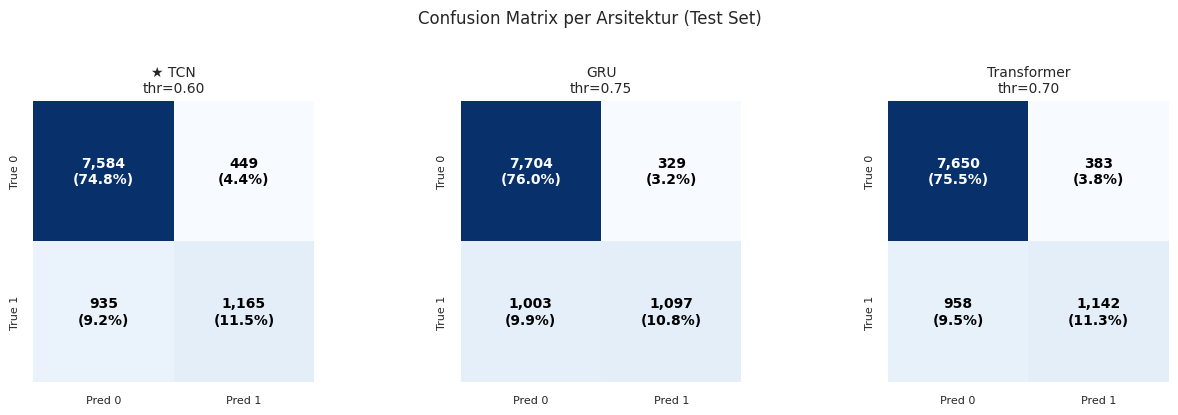

In [ ]:
# Cell 7: Evaluasi clinical-aware time-series per arsitektur.
#
# Reporting metrics:
#   AUROC, AUPRC, PLR, FAR, Median Lead Time, example-level (recall,
#   precision, F1, accuracy, specificity), confusion matrix (TN/FP/FN/TP).

# Selection metric — Time-Series Clinical Utility Score (TS-CUS):
#   TS-CUS = 0.40 × PLR + 0.30 × AUPRC + 0.30 × (1 - FAR)

# Adaptasi dari rubrik tabular dosen (0.30R + 0.25Acc + 0.25F1 + 0.20P)
# ke konteks time-series: Recall→PLR (patient-level), Accuracy→AUPRC
# (threshold-free + imbalanced-aware), F1+Precision→(1-FAR) (alarm fatigue).

# Threshold strategy: maximize TS-CUS pada val set.

# Referensi:
#   PLR: Wardi G, et al. (2021). Ann Emerg Med 77(4):395-406.
#     doi:10.1016/j.annemergmed.2020.11.007
#   AUPRC: Saito & Rehmsmeier (2015). doi:10.1371/journal.pone.0118432
#   FAR: Winters BD, et al. (2018). Crit Care Med 46(1):130-137.

from sklearn.metrics import f1_score, confusion_matrix


def collect_predictions(model, examples, device):
    model.eval()
    probs, labels, stays, ts = [], [], [], []
    with torch.no_grad():
        for ex in examples:
            seq = ex['sequence'].unsqueeze(0).to(device)
            probs.append(torch.sigmoid(model(seq)).item())
            labels.append(ex['label'].item())
            stays.append(ex['stay_id'])
            ts.append(ex['T'])
    return np.array(probs), np.array(labels), np.array(stays), np.array(ts)


def patient_level_metrics(probs, stays, ts, threshold, df):
    """PLR, FAR, Median Lead Time."""
    pred = (probs >= threshold).astype(int)
    stay_onset = df.groupby('stay_id')['t_shock_onset'].first()
    stay_label = df.groupby('stay_id')['has_shock'].first()

    unique_stays   = np.unique(stays)
    shock_stays    = [s for s in unique_stays if stay_label[s] == 1]
    nonshock_stays = [s for s in unique_stays if stay_label[s] == 0]

    detected, lead_times = 0, []
    for s in shock_stays:
        onset = stay_onset[s]
        mask  = (stays == s) & (ts < onset) & (pred == 1)
        if mask.any():
            detected += 1
            lead_times.append(onset - ts[mask].min())

    false_alarmed = sum(
        ((stays == s) & (pred == 1)).any() for s in nonshock_stays
    )

    return {
        'plr'      : detected / len(shock_stays) if shock_stays else 0.0,
        'far'      : false_alarmed / len(nonshock_stays) if nonshock_stays else 0.0,
        'mlt_hours': float(np.median(lead_times)) if lead_times else 0.0,
    }


def ts_cus(plr, auprc, far):
    return 0.40 * plr + 0.30 * auprc + 0.30 * (1.0 - far)


def best_threshold(probs, stays, ts, df, auprc):
    """Maximize TS-CUS pada val (scan 0.05-0.95 step 0.05)."""
    thresholds = np.linspace(0.05, 0.95, 19)
    scores = []
    for t in thresholds:
        pat = patient_level_metrics(probs, stays, ts, t, df)
        scores.append(ts_cus(pat['plr'], auprc, pat['far']))
    return float(thresholds[np.argmax(scores)])


def example_level_metrics(probs, labels, threshold):

    """Example-level metrics + confusion matrix raw counts."""
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, pred, labels=[0, 1]).ravel()
    return {
        'tn'         : int(tn),
        'fp'         : int(fp),
        'fn'         : int(fn),
        'tp'         : int(tp),
        'recall'     : tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'precision'  : tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        'f1'         : f1_score(labels, pred, zero_division=0),
        'accuracy'   : (tp + tn) / len(labels),
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    }


# ── Models + checkpoints ──
MODELS = {
    'GRU'        : (model_gru,         f'{CHECKPOINT_DIR}/best_gru.pt'),
    'TCN'        : (model_tcn,         f'{CHECKPOINT_DIR}/best_tcn.pt'),
    'Transformer': (model_transformer, f'{CHECKPOINT_DIR}/best_transformer.pt'),
}

# evaluasi per arsitektur model
results, thresholds_used = [], {}
confusion_matrices = {}  # untuk visualisasi best model

for name, (model, ckpt) in MODELS.items():
    model.load_state_dict(
        torch.load(ckpt, map_location=device, weights_only=False)['state_dict']
    )
    val_probs,  val_labels,  val_stays,  val_ts  = collect_predictions(
        model, val_examples, device)
    test_probs, test_labels, test_stays, test_ts = collect_predictions(
        model, test_examples, device)

    auroc     = roc_auc_score(test_labels, test_probs)
    auprc     = average_precision_score(test_labels, test_probs)
    val_auprc = average_precision_score(val_labels, val_probs)

    thr = best_threshold(val_probs, val_stays, val_ts, df, val_auprc)
    thresholds_used[name] = thr

    pat = patient_level_metrics(test_probs, test_stays, test_ts, thr, df)
    ex  = example_level_metrics(test_probs, test_labels, thr)
    score = ts_cus(pat['plr'], auprc, pat['far'])

    confusion_matrices[name] = (ex['tn'], ex['fp'], ex['fn'], ex['tp'])

    results.append({
        'model': name, 'auroc': round(auroc, 4), 'auprc': round(auprc, 4),
        'plr': round(pat['plr'], 4), 'far': round(pat['far'], 4),
        'mlt_h': round(pat['mlt_hours'], 1),
        'ts_cus': round(score, 4), 'thr': round(thr, 2),
        **{k: round(v, 4) if isinstance(v, float) else v
           for k, v in ex.items()},
    })

df_results = pd.DataFrame(results).sort_values('ts_cus', ascending=False)
print("Test evaluation (threshold via TS-CUS pada val):\n")
print(df_results.to_string(index=False))

best_name = df_results.iloc[0]['model']
print(f"\nBest architecture: {best_name}")
print("TS-CUS = 0.40*PLR + 0.30*AUPRC + 0.30*(1-FAR)")

# tabel confusion matrix per model
print(f"\nConfusion matrix per model (example-level, test set):")
print(f"{'Model':<12} {'TN':>6} {'FP':>6} {'FN':>6} {'TP':>6}")
print("─" * 42)

for name in df_results['model']:
    tn, fp, fn, tp = confusion_matrices[name]
    print(f"{name:<12} {tn:>6} {fp:>6} {fn:>6} {tp:>6}")

# visualisasi confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, name in zip(axes, df_results['model']):
    tn, fp, fn, tp = confusion_matrices[name]
    cm = np.array([[tn, fp], [fn, tp]])
    cm_pct = cm / cm.sum() * 100

    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                ax=ax, cbar=False, square=True,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])

    # Annotate dengan count + percentage
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.5,
                    f'{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)',
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=10, fontweight='bold')

    is_best = '★ ' if name == best_name else ''
    ax.set_title(f'{is_best}{name}\nthr={thresholds_used[name]:.2f}',
                 fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle('Confusion Matrix per Arsitektur (Test Set)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

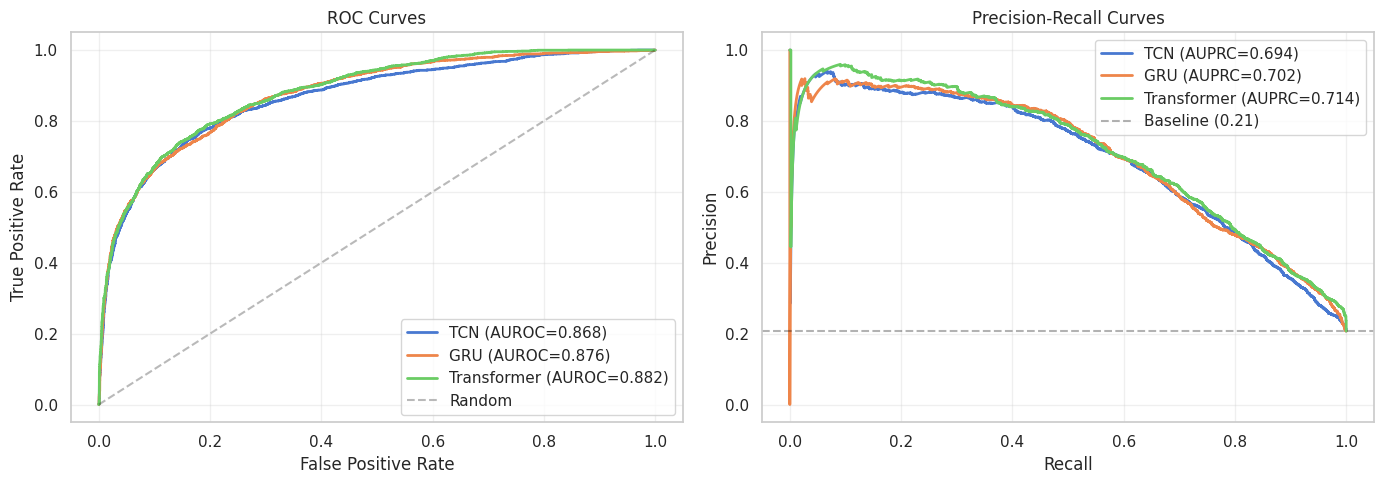

Saved: thesis_artifacts/roc_pr_curves.png


In [ ]:
# Cell 7B: ROC + PR curves multi-model overlay
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in df_results['model']:
    model, ckpt = MODELS[name]
    model.load_state_dict(
        torch.load(ckpt, map_location=device, weights_only=False)['state_dict']
    )
    test_probs, test_labels, _, _ = collect_predictions(model, test_examples, device)

    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    prec, rec, _ = precision_recall_curve(test_labels, test_probs)
    auroc = roc_auc_score(test_labels, test_probs)
    auprc = average_precision_score(test_labels, test_probs)

    axes[0].plot(fpr, tpr, label=f'{name} (AUROC={auroc:.3f})', linewidth=2)
    axes[1].plot(rec, prec, label=f'{name} (AUPRC={auprc:.3f})', linewidth=2)
#end loop

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

prevalence = test_labels.mean()
axes[1].axhline(prevalence, color='black', linestyle='--', alpha=0.3,
                label=f'Baseline ({prevalence:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('thesis_artifacts/roc_pr_curves.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: thesis_artifacts/roc_pr_curves.png")

# cell 8: lead time window


Per lead-time window evaluation (TCN):

 window  n_shock  auprc    plr  mlt_h  ts_cus
Overall     2100 0.6941 0.8797   10.0  0.7763
    ≤6h      673 0.6871 0.7468    6.0  0.7211
  6-12h      367 0.4529 0.6514   11.0  0.6126
 12-24h      372 0.3418 0.5696   20.0  0.5466
 24-48h      260 0.1327 0.4259   37.0  0.4264
   >48h      428 0.1274 0.5000  113.0  0.4544


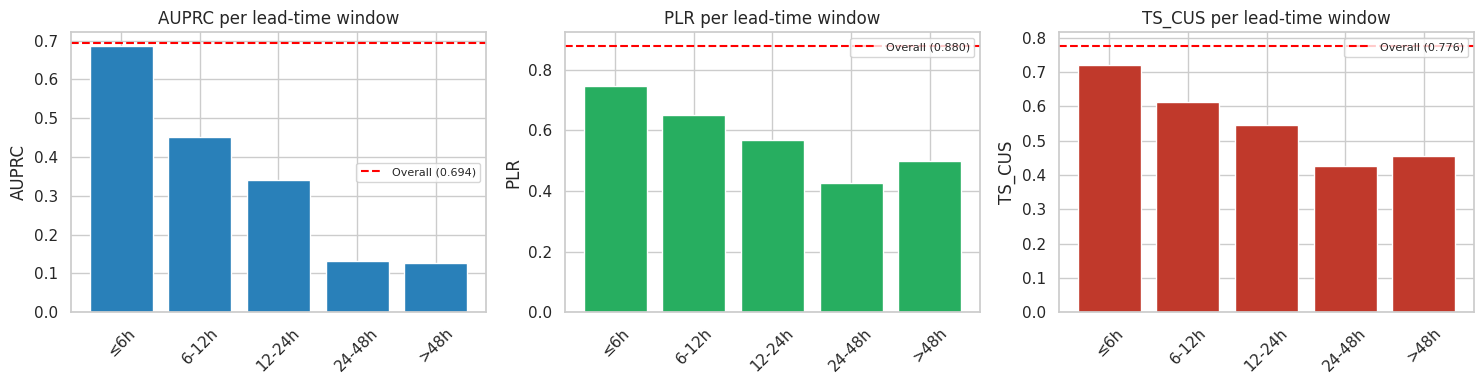

In [ ]:
# Cell 8: Per lead-time window evaluation untuk best model.
# Bucketing test examples by lead_time = onset - T:
#   ≤6h, 6-12h, 12-24h, 24-48h, >48h.
# Compute AUPRC + PLR + TS-CUS per bucket untuk verify temporal
# predictability di berbagai prediction horizons.

import matplotlib.pyplot as plt

# ── Load best model + threshold dari Cell 7 ──
best_model, best_ckpt = MODELS[best_name]
best_model.load_state_dict(
    torch.load(best_ckpt, map_location=device, weights_only=False)['state_dict']
)
thr = thresholds_used[best_name]

test_probs, test_labels, test_stays, test_ts = collect_predictions(
    best_model, test_examples, device)

# ── Compute lead_time untuk shock examples ──
stay_onset = df.groupby('stay_id')['t_shock_onset'].first()
lead_times = np.array([
    stay_onset[s] - t if test_labels[i] == 1 else np.nan
    for i, (s, t) in enumerate(zip(test_stays, test_ts))
])

BUCKETS = [
    ('≤6h',    0,  6),
    ('6-12h',  6,  12),
    ('12-24h', 12, 24),
    ('24-48h', 24, 48),
    ('>48h',   48, np.inf),
]

results = []

# Overall
auprc_all = average_precision_score(test_labels, test_probs)
pat_all   = patient_level_metrics(test_probs, test_stays, test_ts, thr, df)
results.append({
    'window' : 'Overall',
    'n_shock': int((test_labels == 1).sum()),
    'auprc'  : round(auprc_all, 4),
    'plr'    : round(pat_all['plr'], 4),
    'mlt_h'  : round(pat_all['mlt_hours'], 1),
    'ts_cus' : round(ts_cus(pat_all['plr'], auprc_all, pat_all['far']), 4),
})

# Per-bucket
for label, lo, hi in BUCKETS:
    mask_shock_win = (test_labels == 1) & (lead_times > lo) & (lead_times <= hi)
    mask_nonshock  = (test_labels == 0)
    mask           = mask_shock_win | mask_nonshock

    if mask_shock_win.sum() == 0 or len(np.unique(test_labels[mask])) < 2:
        continue

    win_probs  = test_probs[mask]
    win_labels = test_labels[mask]
    win_stays  = test_stays[mask]
    win_ts     = test_ts[mask]

    auprc = average_precision_score(win_labels, win_probs)
    pat   = patient_level_metrics(win_probs, win_stays, win_ts, thr, df)

    results.append({
        'window' : label,
        'n_shock': int(mask_shock_win.sum()),
        'auprc'  : round(auprc, 4),
        'plr'    : round(pat['plr'], 4),
        'mlt_h'  : round(pat['mlt_hours'], 1),
        'ts_cus' : round(ts_cus(pat['plr'], auprc, pat['far']), 4),
    })

df_windows = pd.DataFrame(results)
print(f"Per lead-time window evaluation ({best_name}):\n")
print(df_windows.to_string(index=False))

# ── Visualisasi ──
windows_only = df_windows[df_windows['window'] != 'Overall']
overall_row  = df_windows.iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, color in [
    (axes[0], 'auprc',  '#2980b9'),
    (axes[1], 'plr',    '#27ae60'),
    (axes[2], 'ts_cus', '#c0392b'),
]:
    ax.bar(windows_only['window'], windows_only[metric], color=color)
    ax.axhline(overall_row[metric], color='red', linestyle='--',
               label=f"Overall ({overall_row[metric]:.3f})")
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} per lead-time window')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# cell 9: XAI


Baseline AUPRC (TCN): 0.6941

Running ShapleyValueSampling pada 100 test examples...
  20/100 (20 success)
  40/100 (40 success)
  60/100 (60 success)
  80/100 (80 success)
  100/100 (100 success)

ShapleyValueSampling selesai (100/100 examples success)

Feature ranking (TCN, method=ShapleyValueSampling):

     feature  importance               method
     lactate     1.31243 ShapleyValueSampling
         dbp     0.92331 ShapleyValueSampling
         map     0.80964 ShapleyValueSampling
         sbp     0.58784 ShapleyValueSampling
  creatinine     0.50939 ShapleyValueSampling
        fio2     0.46148 ShapleyValueSampling
    aniongap     0.41146 ShapleyValueSampling
          pt     0.36145 ShapleyValueSampling
         inr     0.33519 ShapleyValueSampling
  baseexcess     0.32948 ShapleyValueSampling
          ph     0.31948 ShapleyValueSampling
         ptt     0.26072 ShapleyValueSampling
         wbc     0.25583 ShapleyValueSampling
 bicarbonate     0.23279 ShapleyValueSampling
ur

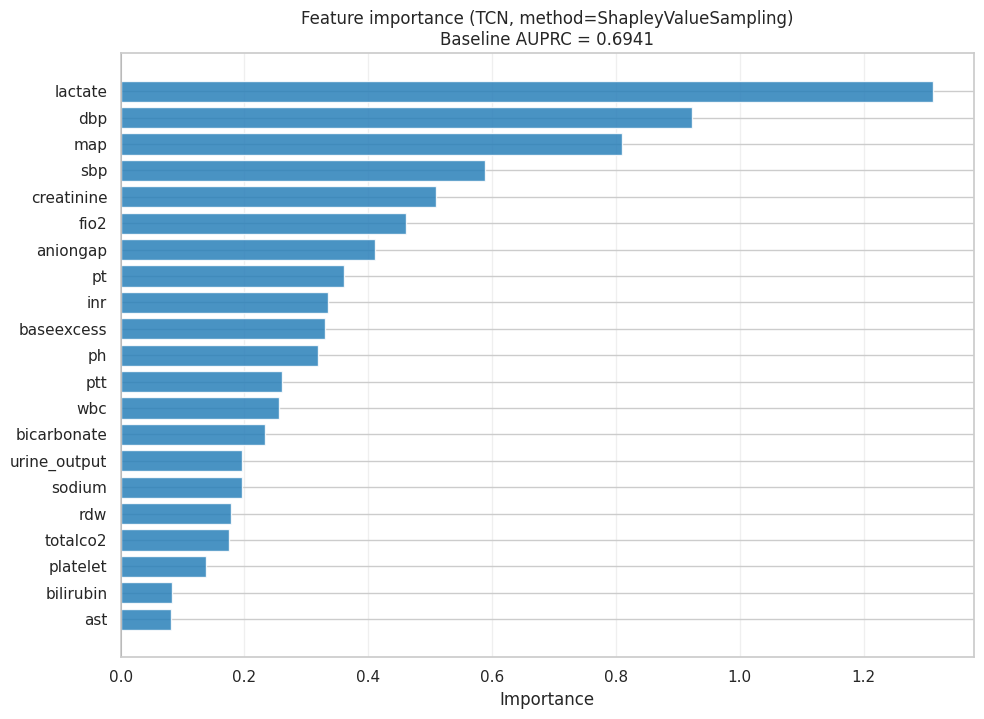

In [ ]:
# cell 9: Feature importance untuk best model via Shapley Value Sampling.

# Metode: ShapleyValueSampling (Captum) — atribusi berbasis nilai Shapley
# untuk model PyTorch. feature_mask mengelompokkan tiap fitur lintas
# seluruh timestep, sehingga keluaran adalah kontribusi Shapley PER FITUR
# (bukan per sel timestep x fitur). Atribusi per-fitur memadai untuk
# pemeringkatan fitur dan kebutuhan antarmuka CDSS.
#
# Output ranking digunakan untuk pemilihan top-K fitur CDSS deployment.
#
# Referensi:
#   Kokhlikyan N, et al. (2020). Captum: A unified and generic model
#     interpretability library for PyTorch. arXiv:2009.07896
#   Strumbelj E, Kononenko I. (2014). Explaining prediction models and
#     individual predictions with feature contributions. Knowl Inf Syst
#     41(3):647-665. doi:10.1007/s10115-013-0679-x

from captum.attr import ShapleyValueSampling

# -- Load best model dari Cell 7 --
best_model, best_ckpt = MODELS[best_name]
best_model.load_state_dict(
    torch.load(best_ckpt, map_location=device, weights_only=False)['state_dict']
)
best_model.eval()

# -- Baseline AUPRC --
test_probs_base, test_labels, test_stays, test_ts = collect_predictions(
    best_model, test_examples, device)
auprc_base = average_precision_score(test_labels, test_probs_base)
print(f"Baseline AUPRC ({best_name}): {auprc_base:.4f}\n")

n_feat = len(FEATURE_COLS_FINAL)

# -- ShapleyValueSampling (Captum) --
# Baseline: median per fitur dari train set (titik referensi "ketiadaan").
train_seqs_flat = np.concatenate(
    [e['sequence'].cpu() for e in train_examples], axis=0
)
baseline_vec = torch.tensor(
    np.median(train_seqs_flat, axis=0), dtype=torch.float32
).to(device)  # shape (F,)

# Wrapper: Captum memanggil forward_func dengan tensor input.
# Model best_model menerima (1, T, F) dan mengembalikan logit skalar;
# kembalikan sebagai tensor shape (1,) agar konsisten dengan API Captum.
def forward_func(x):
    # x: (1, T, F)
    logit = best_model(x)
    return logit.reshape(1)

explainer = ShapleyValueSampling(forward_func)

# Subsample examples untuk efisiensi komputasi.
N_EXPLAIN = 100
rng_idx = np.random.default_rng(RANDOM_SEED)
n_pool  = len(test_examples)
explain_idx = rng_idx.choice(
    n_pool, min(N_EXPLAIN, n_pool), replace=False)

print(f"Running ShapleyValueSampling pada {len(explain_idx)} "
      f"test examples...")

shap_per_feature = np.zeros(n_feat)
n_success = 0

for idx_i, i in enumerate(explain_idx):
    seq = test_examples[i]['sequence']          # (T, F)
    T   = seq.shape[0]
    x_input  = seq.unsqueeze(0).to(device)      # (1, T, F)

    # Baseline broadcast ke bentuk input (1, T, F).
    # .contiguous() wajib: Captum memanggil .view(-1) pada mask
    # secara internal; tensor hasil expand() tidak kontigu sehingga
    # .view akan gagal tanpa .contiguous().
    baselines = (baseline_vec.view(1, 1, n_feat)
                 .expand(1, T, n_feat).contiguous())

    # feature_mask: tiap kolom fitur diberi label grup sama di semua
    # timestep -> Captum menghitung 1 nilai Shapley per fitur.
    feat_mask = (torch.arange(n_feat, device=device)
                 .view(1, 1, n_feat)
                 .expand(1, T, n_feat).contiguous())

    attr = explainer.attribute(
        x_input,
        baselines=baselines,
        feature_mask=feat_mask,
        n_samples=25,
        perturbations_per_eval=1,  # model dirancang batch=1
        show_progress=False,
    )
    # attr: (1, T, F). Tiap kolom fitur seragam antar timestep
    # (akibat feature_mask). Ambil nilai absolut, agregasi per fitur.
    attr_np = attr.detach().cpu().numpy()[0]   # (T, F)
    shap_per_feature += np.abs(attr_np).mean(axis=0)  # (F,)
    n_success += 1

    if (idx_i + 1) % 20 == 0:
        print(f"  {idx_i + 1}/{len(explain_idx)} ({n_success} success)")

shap_per_feature /= n_success

feature_ranking = (pd.DataFrame({
    'feature'   : FEATURE_COLS_FINAL,
    'importance': shap_per_feature,
}).sort_values('importance', ascending=False)
   .reset_index(drop=True))
feature_ranking['method'] = 'ShapleyValueSampling'

print(f"\nShapleyValueSampling selesai "
      f"({n_success}/{len(explain_idx)} examples)")

# output
print(f"\nFeature ranking ({best_name}, method=ShapleyValueSampling):\n")
print(feature_ranking.round(5).to_string(index=False))

FEATURE_RANKING = feature_ranking['feature'].tolist()
print(f"\nFEATURE_RANKING (sorted by importance, descending):")
print(f"  {FEATURE_RANKING}")

# visualisasi
fig, ax = plt.subplots(figsize=(10, max(4, n_feat * 0.35)))
y_pos = np.arange(len(feature_ranking))
colors = ['#2980b9' if v > 0 else '#bdc3c7'
          for v in feature_ranking['importance']]

ax.barh(y_pos, feature_ranking['importance'],
        color=colors, alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_ranking['feature'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Importance')
ax.set_title(f'Feature importance ({best_name}, method=ShapleyValueSampling)\n'
             f'Baseline AUPRC = {auprc_base:.4f}')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Cell 10: final summary

Saving predictions per model...
  → thesis_artifacts/predictions_per_model.csv (30,399 rows)
Saving training histories...
  → thesis_artifacts/training_histories.csv (31 rows)
Saving feature ranking...
  → thesis_artifacts/feature_ranking.csv (21 fitur)
Saving cohort metadata...
  → thesis_artifacts/cohort_metadata.csv (4,626 stays)


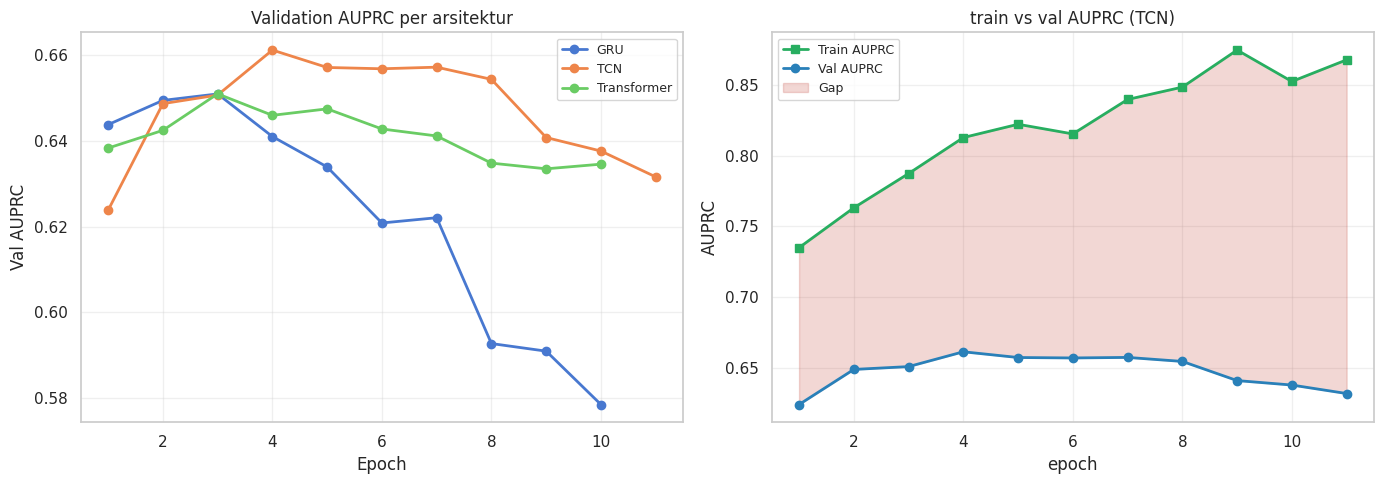

  → thesis_artifacts/training_curves.png

FINAL SUMMARY untuk BAB 4

kohort: 4,626 stay (1,046 syok, 3,580 non-syok, 22.6% prevalence)
train/val/test: 3,238 / 693 / 695 stays
features: 21 (mRMR natural stop)
  → ['lactate', 'bilirubin', 'baseexcess', 'sbp', 'aniongap', 'inr', 'bicarbonate', 'totalco2', 'pt', 'fio2', 'map', 'urine_output', 'creatinine', 'platelet', 'dbp', 'ast', 'ptt', 'ph', 'wbc', 'rdw', 'sodium']

Model performance (test set):
      model  auroc  auprc    plr    far  mlt_h  ts_cus  thr   tn  fp   fn   tp  recall  precision     f1  accuracy  specificity
        TCN 0.8675 0.6941 0.8797 0.2793   10.0  0.7763 0.60 7584 449  935 1165  0.5548     0.7218 0.6274    0.8634       0.9441
        GRU 0.8762 0.7022 0.8101 0.2086    9.5  0.7721 0.75 7704 329 1003 1097  0.5224     0.7693 0.6222    0.8685       0.9590
Transformer 0.8824 0.7138 0.8165 0.2439   11.0  0.7675 0.70 7650 383  958 1142  0.5438     0.7489 0.6301    0.8677       0.9523

Best architecture: TCN
  Test AUPRC: 0

In [ ]:
# Cell 11: Final summary + export artifacts untuk thesis writeup.

# Output files:
#   - predictions_per_model.csv : test set probs + labels + metadata
#   - training_histories.csv    : epoch-by-epoch metrics semua arsitektur
#   - feature_ranking.csv       : output Cell 9 untuk CDSS deployment
#   - cohort_metadata.csv       : stay_id + label + split untuk reproducibility
#   - training_curves.png       : trajectory val AUPRC + train-val gap

# Print structured summary untuk paste ke BAB 4.

import os

OUTPUT_DIR = 'thesis_artifacts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Predictions per model ──
print("Saving predictions per model...")
all_predictions = []
for name, (model, ckpt) in MODELS.items():
    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=False)['state_dict'])
    probs, labels, stays, ts = collect_predictions(model, test_examples, device)
    for p, l, s, t in zip(probs, labels, stays, ts):
        all_predictions.append({
            'model'   : name,
            'stay_id' : int(s),
            'T'       : int(t),
            'prob'    : float(p),
            'label'   : int(l),
        })
df_predictions = pd.DataFrame(all_predictions)
df_predictions.to_csv(f'{OUTPUT_DIR}/predictions_per_model.csv', index=False)
print(f"  → {OUTPUT_DIR}/predictions_per_model.csv "
      f"({len(df_predictions):,} rows)")

# ── 2. Training histories ──
print("Saving training histories...")
histories = {
    'GRU'        : gru_history,
    'TCN'        : tcn_history,
    'Transformer': transformer_history,
}
all_history = []
for name, hist in histories.items():
    for record in hist:
        all_history.append({'model': name, **record})
df_history = pd.DataFrame(all_history)
df_history.to_csv(f'{OUTPUT_DIR}/training_histories.csv', index=False)
print(f"  → {OUTPUT_DIR}/training_histories.csv "
      f"({len(df_history):,} rows)")

# ── 3. Feature ranking ──
print("Saving feature ranking...")
feature_ranking.to_csv(f'{OUTPUT_DIR}/feature_ranking.csv', index=False)
print(f"  → {OUTPUT_DIR}/feature_ranking.csv "
      f"({len(feature_ranking)} fitur)")

# ── 4. Cohort metadata ──
print("Saving cohort metadata...")
stay_label = df.groupby('stay_id')['has_shock'].first()
stay_onset = df.groupby('stay_id')['t_shock_onset'].first()

split_map = {}
for s in train_stays: split_map[int(s)] = 'train'
for s in val_stays:   split_map[int(s)] = 'val'
for s in test_stays:  split_map[int(s)] = 'test'

cohort_meta = pd.DataFrame({
    'stay_id'       : list(split_map.keys()),
    'has_shock'     : [int(stay_label[s]) for s in split_map.keys()],
    't_shock_onset' : [float(stay_onset[s]) if pd.notna(stay_onset[s]) else None
                       for s in split_map.keys()],
    'split'         : list(split_map.values()),
})
cohort_meta.to_csv(f'{OUTPUT_DIR}/cohort_metadata.csv', index=False)
print(f"  → {OUTPUT_DIR}/cohort_metadata.csv "
      f"({len(cohort_meta):,} stays)")

# ── 5. Visualisasi training trajectories ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Val AUPRC trajectory 5 arsitektur
for name, hist in histories.items():
    epochs    = [h['epoch']     for h in hist]
    val_auprc = [h['val_auprc'] for h in hist]
    axes[0].plot(epochs, val_auprc, marker='o', label=name, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val AUPRC')
axes[0].set_title('Validation AUPRC per arsitektur')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: Train vs val untuk best model (overfitting analysis)
best_hist = histories[best_name]
epochs    = [h['epoch']     for h in best_hist]
tr_auprc  = [h['tr_auprc']  for h in best_hist]
val_auprc = [h['val_auprc'] for h in best_hist]

axes[1].plot(epochs, tr_auprc,  marker='s', color='#27ae60',
             label='Train AUPRC', linewidth=2)
axes[1].plot(epochs, val_auprc, marker='o', color='#2980b9',
             label='Val AUPRC', linewidth=2)
axes[1].fill_between(epochs, val_auprc, tr_auprc,
                     alpha=0.2, color='#c0392b', label='Gap')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('AUPRC')
axes[1].set_title(f'train vs val AUPRC ({best_name})')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  → {OUTPUT_DIR}/training_curves.png")

# ── Final summary ──
print(f"\n{'='*70}")
print("FINAL SUMMARY untuk BAB 4")
print(f"{'='*70}")

n_total = len(cohort_meta)
n_shock = int(cohort_meta['has_shock'].sum())
print(f"\nkohort: {n_total:,} stay ({n_shock:,} syok, "
      f"{n_total-n_shock:,} non-syok, {n_shock/n_total*100:.1f}% prevalence)")
n_train = (cohort_meta['split'] == 'train').sum()
n_val   = (cohort_meta['split'] == 'val').sum()
n_test  = (cohort_meta['split'] == 'test').sum()
print(f"train/val/test: {n_train:,} / {n_val:,} / {n_test:,} stays")
print(f"features: {len(FEATURE_COLS_FINAL)} (mRMR natural stop)")
print(f"  → {FEATURE_COLS_FINAL}")

print(f"\nModel performance (test set):")
print(df_results.to_string(index=False))

print(f"\nBest architecture: {best_name}")
print(f"  Test AUPRC: {df_results.iloc[0]['auprc']:.4f}")
print(f"  Test AUROC: {df_results.iloc[0]['auroc']:.4f}")
print(f"  PLR: {df_results.iloc[0]['plr']:.4f}")
print(f"  FAR: {df_results.iloc[0]['far']:.4f}")
print(f"  Median Lead Time: {df_results.iloc[0]['mlt_h']:.1f} hours")

print(f"\nPer lead-time window:")
print(df_windows.to_string(index=False))

print(f"\nFeature ranking (method={feature_ranking['method'].iloc[0]}):")
print(feature_ranking[['feature', 'importance']].round(5).to_string(index=False))

print(f"\nArtifacts saved to: {OUTPUT_DIR}/")
print(f"  - predictions_per_model.csv")
print(f"  - training_histories.csv")
print(f"  - feature_ranking.csv")
print(f"  - cohort_metadata.csv")
print(f"  - training_curves.png")

In [ ]:
# download artifact
import shutil
shutil.make_archive('thesis_artifacts', 'zip', 'thesis_artifacts')

from google.colab import files
files.download('thesis_artifacts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>